# SQL-02 · Analisis Keranjang Belanja dengan DuckDB + Python
### Bundel apa yang layak dibiayai kampanye Ramadan Rp 80 juta?

**Analis:** Aulia Aorama · **Pemangku kepentingan:** Mbak Dian (Head of Product/Merchandising) · **Data:** `order_items.csv`

Notebook ini adalah **sumber seluruh angka dan seluruh grafik**. Keenam gambar di lampiran bukti dan portofolio dibuat di sini dan disimpan di folder `grafik/`; kedua PDF itu memakai file PNG yang sama persis. Keterangan tiap gambar (apa yang tergambar, cara membaca, rentang data, yang terlihat) sama kata per kata dengan lampiran dan portofolio, dan tabel keputusan, rekomendasi, dan batas di Langkah 6 sama dengan catatan keputusan.

| Gambar di notebook | Dipakai di |
|---|---|
| Gambar 1 · sebar 105 pasangan | Lampiran Gambar 1, portofolio halaman 1 |
| Gambar 2 · batas maksimum dan ruang tumbuh | Lampiran Gambar 2, portofolio halaman 2 |
| Gambar 3 · lintas kategori lawan satu kategori | Lampiran Gambar 3 |
| Gambar 4 · dua belas cara menghitung ulang | Lampiran Gambar 4, portofolio halaman 2 |
| Gambar 5 · ambang bukti digeser | Lampiran Gambar 5 |
| Gambar 6 · satu data, tiga cara mengurutkan | Portofolio PDF halaman 2, dan grafik interaktif di pembuka portofolio HTML (angkanya dibaca dari `grafik/gambar6_data.json`) |
| Grafik kerja A sampai D | Tidak masuk lampiran; alasannya ditulis di sel masing-masing dan di lampiran |

**Hasil akhirnya:**
- **Tiga bundel layak diuji:** Matte Lip Cream + Lip Liner, Brightening Serum + Eye Cream, Daily Moisturizer + Sunscreen SPF50.
- **Satu pasangan sengaja ditolak** meski angkanya paling mencolok: Eye Primer + Eyeliner Pen.
- **Hasilnya tidak berubah di dua belas cara menghitung ulang**, dan tidak berubah untuk ambang mana pun antara 200 dan 1.200.
- **Rekomendasinya berbentuk uji dengan kelompok pembanding.**

### Daftar istilah
| Istilah | Artinya |
|---|---|
| **Keranjang** | Satu order, berisi daftar produk yang dibeli (tiap produk dihitung sekali). |
| **Support** | Berapa keranjang yang memuat kedua produk. Ukuran **seberapa besar**. |
| **Confidence** | Dari keranjang yang memuat A, berapa persen yang juga memuat B. Bisa berbeda kalau arahnya dibalik. |
| **Lift** | Berapa kali lebih sering dua produk muncul bersama dibanding kebetulan. 1 berarti persis kebetulan. |
| **Batas maksimum lift** | Lift tertinggi yang **mungkin** dicapai sebuah pasangan. Makin populer produknya, makin rendah batasnya. |
| **z** | Seberapa kecil kemungkinan pola ini kebetulan. Di atas 1,96 lazim dianggap bukan kebetulan. |
| **Ambang bukti** | Jumlah keranjang minimum sebelum pasangan boleh direkomendasikan. **Keputusan analis**, bukan hasil data. |
| **Ruang tumbuh** | Jumlah keranjang yang baru memuat **salah satu** produk bundel. Di situlah bundel bisa menambah produk kedua. |

## 0 · Persiapan

Sel pertama memuat data. Sel kedua adalah **pustaka grafik bersama**: fungsi yang sama membuat setiap gambar di lampiran dan portofolio.

In [1]:
# Sel ini berjalan di tiga tempat tanpa diubah: Google Colab, folder repositori GitHub, atau satu folder biasa.
import os, sys, subprocess, urllib.request
def pastikan(paket, versi_min=None):
    try:
        mod = __import__(paket)
        if versi_min and tuple(int(x) for x in mod.__version__.split(".")[:2]) < versi_min:
            raise ImportError
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", paket], check=True)
pastikan("duckdb", (1, 1))          # fungsi query_table() butuh DuckDB 1.1 ke atas

import duckdb, numpy as np, pandas as pd

# Cari data di folder kerja, lalu di struktur repositori; kalau tidak ada (misalnya di Colab), unduh dari GitHub.
REPO_RAW = "https://raw.githubusercontent.com/aoramaaulia-collab/Market-Basket-Bundle-Analysis/main/data/order_items.csv"
CSV = next((p for p in ["order_items.csv", "data/order_items.csv", "../data/order_items.csv"] if os.path.exists(p)), None)
if CSV is None:
    urllib.request.urlretrieve(REPO_RAW, "order_items.csv"); CSV = "order_items.csv"
# Grafik disimpan di folder grafik/ di akar proyek (folder induk dari data/), supaya portofolio menemukannya.
CSV = os.path.abspath(CSV)
folder_data = os.path.dirname(CSV)
DASAR = os.path.dirname(folder_data) if os.path.basename(folder_data) == "data" else folder_data
os.chdir(DASAR)
print("Data dibaca dari:", os.path.relpath(CSV))

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE TABLE order_items AS SELECT * FROM read_csv_auto('{CSV}')")
def q(sql):      return con.execute(sql).df()
def nilai(sql):  return con.execute(sql).fetchone()[0]
q("DESCRIBE order_items")[["column_name", "column_type"]]

Data dibaca dari: data/order_items.csv


,column_name,column_type
0,OrderID,VARCHAR
1,ProductID,VARCHAR
2,ProductName,VARCHAR
3,Category,VARCHAR
4,Quantity,BIGINT
5,Price,BIGINT
6,OrderDate,DATE


In [2]:
# ===== PUSTAKA GRAFIK BERSAMA =====
# Kode ini dipakai notebook untuk membuat SELURUH grafik lampiran dan portofolio.
# PNG yang disimpan di folder grafik/ adalah file yang sama yang ditempel ke kedua PDF.
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FixedLocator, NullLocator

BIRU, ORANYE, ABU, GELAP, HIJAU = "#1b6ca8", "#d9822b", "#a3a9ae", "#3d4852", "#2e9e83"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titlelocation": "left", "axes.titleweight": "bold",
                     "axes.titlesize": 10.5, "axes.grid": True, "grid.color": "#e6e8ea", "axes.axisbelow": True,
                     "savefig.dpi": 220, "savefig.bbox": "tight"})

def ribu(x, *_):
    return f"{int(round(x)):,}".replace(",", ".")
def des(x, d=2):
    return f"{x:,.{d}f}".replace(",", "X").replace(".", ",").replace("X", ".")
F_RIBU = FuncFormatter(ribu)

def _log_y(ax, ticks=(1, 2, 5, 10)):
    ax.set_yscale("log"); ax.yaxis.set_major_locator(FixedLocator(list(ticks)))
    ax.yaxis.set_minor_locator(NullLocator()); ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: ribu(v)))

def _simpan(fig, out):
    if out:
        os.makedirs(os.path.dirname(out) or ".", exist_ok=True)
        fig.savefig(out)
    return fig

def gambar_sebar(m, bundel, jebakan, anon=False, out=None, ukuran=(8.6, 4.3)):
    """Gambar 1: kekuatan hubungan lawan besar bukti, seluruh pasangan.
    m: tabel pasangan (pa, pb, bersama, lift). bundel: daftar (pa, pb) urut lift. jebakan: (pa, pb)."""
    kecil = ukuran[0] < 8
    fig, ax = plt.subplots(figsize=ukuran)
    kunci = list(zip(m.pa, m.pb))
    is_b = np.array([k in bundel for k in kunci]); is_j = np.array([k == jebakan for k in kunci]); s = ~(is_b | is_j)
    mb = m[is_b].set_index(["pa", "pb"]).loc[bundel].reset_index(); mj = m[is_j].iloc[0]
    ax.scatter(m.bersama[s], m.lift[s], s=22, color=ABU, alpha=.8, label=f"{int(s.sum())} pasangan lain", zorder=2)
    ax.scatter(mb.bersama, mb.lift, s=95, color=BIRU, zorder=3,
               label="tiga bundel yang diusulkan" + (" (nomor = bundel)" if anon else ""))
    ax.scatter([mj.bersama], [mj.lift], s=130, facecolors="white", edgecolors=ORANYE, linewidths=2.4,
               label="pasangan yang ditolak", zorder=3)
    ax.axhline(1, color=GELAP, ls="--", lw=1)
    ax.text(1430, 1.03, "garis kebetulan (1 kali lipat)", ha="right", va="bottom", fontsize=8, color=GELAP)
    ax.axvline(200, color=ORANYE, ls=":", lw=1.3)
    ax.text(215, 6.2, "ambang bukti\n200 keranjang", fontsize=8, color=ORANYE)
    if anon:
        for i, r in enumerate(mb.itertuples(), 1):
            ax.annotate(f"{i}", (r.bersama, r.lift), ha="center", va="center", fontsize=7.5, color="white",
                        fontweight="bold", zorder=5)
    ax.annotate(f"{ribu(mj.bersama)} keranjang," + ("\n" if kecil else " ") + f"{des(mj.lift)} kali lipat",
                (mj.bersama, mj.lift), xytext=(240, mj.lift), textcoords="data", fontsize=8.5, color=ORANYE,
                va="center", arrowprops=dict(arrowstyle="-", color=ORANYE, lw=.9, shrinkA=0, shrinkB=7))
    ax.annotate(f"{ribu(mb.bersama.min())} sampai {ribu(mb.bersama.max())} keranjang,\n"
                f"{des(mb.lift.min())} sampai {des(mb.lift.max())} kali lipat", (mb.bersama[0], mb.lift[0]),
                xytext=(-150, 42), textcoords="offset points", fontsize=8.5, color=BIRU,
                arrowprops=dict(arrowstyle="-", color=BIRU, lw=.9))
    _log_y(ax); ax.set_ylim(.82, 20); ax.set_xlim(-30, 1470)
    ax.xaxis.set_major_formatter(F_RIBU)
    ax.set_xlabel("jumlah keranjang yang memuat kedua produk")
    ax.set_ylabel("berapa kali lipat dari kebetulan (skala log)")
    ax.set_title("105 pasangan produk: kekuatan hubungan lawan besar bukti")
    ax.legend(frameon=False, fontsize=8, loc="upper right")
    return _simpan(fig, out)

def gambar_batas_ruang(baris, anon=False, out=None):
    """Gambar 2: kekuatan dibanding batas maksimumnya (kiri) dan ruang tumbuh tiap bundel (kanan).
    baris: daftar dict dengan kunci nama, nama_anon, lift, batas, persen, ruang (None untuk yang ditolak), ditolak."""
    fig, ax = plt.subplots(1, 2, figsize=(9.8, 3.3), gridspec_kw={"width_ratios": [1.3, 1]})
    lab = [r["nama_anon"] if anon else r["nama"] for r in baris]
    y = np.arange(len(baris))[::-1]
    for yy, r in zip(y, baris):
        col = ORANYE if r["ditolak"] else BIRU
        ax[0].barh(yy, 100, color="#f1f3f4", height=.62)
        ax[0].barh(yy, r["persen"], color=col, height=.62)
        ax[0].text(r["persen"] - 2, yy, f"{des(r['persen'], 1)}%", va="center", ha="right",
                   fontsize=8.5, color="white", fontweight="bold")
        ax[0].text(102, yy, f"lift {des(r['lift'])}\ndari batas {des(r['batas'])}", va="center", fontsize=7.6)
    ax[0].set_xlim(0, 125); ax[0].set_xticks([0, 25, 50, 75, 100])
    ax[0].xaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{int(v)}%"))
    ax[0].set_yticks(y); ax[0].set_yticklabels(lab, fontsize=8)
    ax[0].set_xlabel("lift sebagai persentase dari batas maksimum yang mungkin")
    ax[0].set_title("Seberapa dekat dengan batas maksimumnya"); ax[0].grid(axis="y", visible=False)
    bb = [r for r in baris if not r["ditolak"]]
    yb = np.arange(len(bb))[::-1]
    for yy, r in zip(yb, bb):
        ax[1].barh(yy, r["ruang"], color=HIJAU, height=.6)
        ax[1].text(r["ruang"] + 12, yy, f"{ribu(r['ruang'])} keranjang", va="center", fontsize=8)
    ax[1].set_yticks(yb); ax[1].set_yticklabels([r["nama_anon"] if anon else r["nama"] for r in bb], fontsize=8)
    ax[1].set_xlim(0, 900); ax[1].xaxis.set_major_formatter(F_RIBU)
    ax[1].set_xlabel("keranjang yang memuat salah satu saja")
    ax[1].set_title("Ruang tumbuh tiap bundel"); ax[1].grid(axis="y", visible=False)
    fig.tight_layout(w_pad=2.5)
    return _simpan(fig, out)

def gambar_kategori(m, jebakan, out=None):
    """Gambar 3: lift seluruh pasangan dipisah lintas kategori dan satu kategori.
    m: tabel pasangan (pa, pb, lift, z, lintas). jebakan: (pa, pb)."""
    fig, ax = plt.subplots(figsize=(8.6, 3.5)); rng = np.random.default_rng(3)
    for xi, lintas in enumerate([True, False]):
        g = m[m.lintas == lintas]
        nyata = ((g.lift > 1) & (g.z > 1.96)).values
        isj = np.array([(a, b) == jebakan for a, b in zip(g.pa, g.pb)])
        jx = xi + rng.uniform(-.17, .17, len(g))
        ax.scatter(jx[~nyata], g.lift[~nyata], s=20, color=ABU, alpha=.85, zorder=2)
        ax.scatter(jx[nyata & ~isj], g.lift[nyata & ~isj], s=70, color=BIRU, zorder=3)
        ax.scatter(jx[isj], g.lift[isj], s=90, facecolors="white", edgecolors=ORANYE, lw=2.2, zorder=3)
        med = g.lift.median()
        ax.plot([xi-.3, xi+.3], [med, med], color=GELAP, lw=2, zorder=4)
        ax.text(xi+.33, med, f"median {des(med, 3)}", va="center", fontsize=8, color=GELAP)
        extra = " (1 di antaranya ditolak)" if isj.any() else ""
        ax.text(xi, 38, f"{len(g)} pasangan\n{int(nyata.sum())} hubungan nyata{extra}", ha="center", va="top", fontsize=8.5)
    _log_y(ax); ax.set_ylim(.8, 42); ax.set_xlim(-.6, 1.9)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["lintas kategori", "satu kategori"])
    ax.set_ylabel("kali lipat dari kebetulan (skala log)")
    ax.set_title("Lift seluruh pasangan, dipisah menurut jenis kategori"); ax.grid(axis="x", visible=False)
    return _simpan(fig, out)

def gambar_dua_belas(tabel, kolom, anon=False, out=None):
    """Gambar 4: dua belas cara menghitung ulang.
    tabel: daftar dict {label, ambang, sel: {kunci: (keranjang, lift, lolos)}}.
    kolom: daftar (kunci, nama, nama_anon)."""
    X0, W = 3.3, 1.22
    fig, ax = plt.subplots(figsize=(10.4, 4.7))
    ax.set_xlim(0, X0 + len(kolom)*W + .05); ax.set_ylim(0, len(tabel) + 1.1); ax.axis("off")
    ax.text(0.02, len(tabel) + .5, "cara menghitung", fontsize=8, fontweight="bold", color=GELAP, va="center")
    ax.text(X0 - .1, len(tabel) + .5, "ambang", fontsize=8, fontweight="bold", color=GELAP, va="center", ha="right")
    for j, (_, nm, nma) in enumerate(kolom):
        ax.text(X0 + W*j + W/2, len(tabel) + .5, (nma if anon else nm).replace(" + ", "\n+ "), ha="center",
                va="center", fontsize=7, fontweight="bold", color=GELAP)
    for i, r in enumerate(tabel):
        yy = len(tabel) - i - .5
        ax.text(0.02, yy, r["label"], va="center", fontsize=7.8)
        ax.text(X0 - .1, yy, ribu(r["ambang"]), va="center", ha="right", fontsize=7.8, color=GELAP)
        for j, (k, _, _) in enumerate(kolom):
            b, lift, ok = r["sel"][k]
            ax.add_patch(plt.Rectangle((X0 + W*j + .04, yy - .42), W - .08, .84,
                                       color="#dbe9f5" if ok else "#fbe7d3", lw=0))
            ax.text(X0 + W*j + W/2, yy, f"{ribu(b)} · {des(lift)}x", ha="center", va="center", fontsize=7.4)
    ax.set_title("Dua belas cara menghitung ulang. Isi sel: keranjang penopang · kali lipat dari kebetulan.\n"
                 "Biru = lolos ketiga syarat, oranye = tidak lolos.", fontsize=9.5)
    return _simpan(fig, out)

def gambar_ambang(sens, ambang_dipilih=200, out=None):
    """Gambar 5: ambang bukti digeser, dua susunan saringan berdampingan.
    sens: tabel (ambang, lift_saja, tiga_syarat)."""
    fig, ax = plt.subplots(1, 2, figsize=(9.8, 3.2), sharey=True)
    for i, (k, judul) in enumerate([("lift_saja", "Saringan: lift di atas 1 saja"),
                                    ("tiga_syarat", "Saringan: ketiga syarat")]):
        ax[i].bar(range(len(sens)), sens[k], width=.65,
                  color=[BIRU if a == ambang_dipilih else ABU for a in sens.ambang])
        ax[i].set_xticks(range(len(sens)))
        ax[i].set_xticklabels([ribu(a) for a in sens.ambang], fontsize=7.5, rotation=45)
        for x, v in enumerate(sens[k]):
            ax[i].text(x, v + .8, str(int(v)), ha="center", fontsize=8)
        ax[i].set_title(judul); ax[i].set_xlabel("ambang bukti (minimal keranjang)")
        ax[i].grid(axis="x", visible=False)
    ax[0].set_ylabel("pasangan yang lolos"); ax[0].set_ylim(0, 52)
    fig.tight_layout()
    return _simpan(fig, out)

def gambar_tiga_urutan(baris, anon=False, out=None, data_out=None):
    """Gambar 6: satu data, tiga cara mengurutkan.
    baris: daftar dict dengan kunci nama, nama_anon, ditolak, lift, keranjang, persen_batas.
    data_out: bila diisi, angka yang sama disimpan sebagai JSON untuk grafik interaktif portofolio HTML."""
    import json
    ukuran = [("lift", "Urut menurut kekuatan hubungan", lambda v: f"{des(v)}x"),
              ("keranjang", "Urut menurut jangkauan", lambda v: f"{ribu(v)} keranjang"),
              ("persen_batas", "Urut menurut kekuatan dibanding batasnya", lambda v: f"{des(v, 1)}%")]
    fig, ax = plt.subplots(1, 3, figsize=(11.2, 2.9))
    for a, (k, judul, fmt) in zip(ax, ukuran):
        urut = sorted(baris, key=lambda r: r[k])
        y = np.arange(len(urut))
        maks = max(r[k] for r in urut)
        a.barh(y, [r[k] for r in urut], color=[ORANYE if r["ditolak"] else BIRU for r in urut], height=.62)
        for yy, r in zip(y, urut):
            a.text(r[k] + maks * .02, yy, fmt(r[k]), va="center", fontsize=7.8)
        a.set_yticks(y); a.set_yticklabels([r["nama_anon"] if anon else r["nama"] for r in urut], fontsize=7.6)
        a.set_xlim(0, maks * 1.45); a.set_xticks([]); a.spines["bottom"].set_visible(False)
        a.set_title(judul, fontsize=9.2); a.grid(False)
    fig.tight_layout(w_pad=1.5)
    if data_out:
        os.makedirs(os.path.dirname(data_out) or ".", exist_ok=True)
        json.dump([{"nama": r["nama_anon"], "ditolak": bool(r["ditolak"]), "lift": float(r["lift"]),
                    "keranjang": int(r["keranjang"]), "batas": float(r["persen_batas"])} for r in baris],
                  open(data_out, "w"), ensure_ascii=False, indent=1)
    return _simpan(fig, out)

from IPython.display import Image, display
print('Pustaka grafik siap. Semua gambar disimpan ke folder grafik/.')

Pustaka grafik siap. Semua gambar disimpan ke folder grafik/.


---
# Langkah 1 · Situasi
- **Anggaran Rp 80 juta** habis untuk potongan harga, materi visual per paket, tempat di halaman depan, dan dorongan berbayar.
- Akibatnya **tiap bundel memakan porsi anggaran yang sama besar entah ia laku atau tidak**.
- **Tanggal mati Ramadan:** analisis yang benar tetapi terlambat dua minggu nilainya sama dengan analisis yang keliru.

> **Aturan sepanjang notebook: tiap angka menyebut penyebutnya.** "146 dari 3.000 keranjang", bukan "146 kali".

---
# Langkah 2 · Pertanyaan yang benar
## 2.1 Kueri naif yang berjalan mulus
Kueri ini sengaja dijalankan dulu, untuk melihat bahwa **hasil yang keliru tidak tampak keliru**.

In [3]:
q("""SELECT a.ProductName AS produk_a, b.ProductName AS produk_b, count(*) AS bersama
     FROM order_items a JOIN order_items b ON a.OrderID = b.OrderID
     WHERE a.ProductID < b.ProductID GROUP BY 1, 2 ORDER BY bersama DESC LIMIT 10""")

,produk_a,produk_b,bersama
0,Daily Moisturizer,Sunscreen SPF50,1591
1,Brightening Serum,Eye Cream,1512
2,Matte Lip Cream,Lip Liner,1416
3,Daily Moisturizer,Eye Cream,1204
4,Brightening Serum,Daily Moisturizer,1097
5,Daily Moisturizer,Lip Liner,1090
6,Sunscreen SPF50,Eye Cream,1059
7,Daily Moisturizer,Matte Lip Cream,997
8,Lip Liner,Eye Cream,987
9,Brightening Serum,Sunscreen SPF50,939


Rapi dan siap masuk slide, tetapi diam-diam mengambil **tiga keputusan**: semua baris dianggap sah; satu produk yang tercatat dua kali dihitung dua kali (di self-join, baris ganda **mengalikan**); dan `LIMIT 10` mengambil teratas **tanpa bertanya apakah buktinya cukup**.

## 2.2 Pertanyaan kerja yang lengkap
> *"Dengan **keranjang didefinisikan** sebagai himpunan produk unik per order dari item yang sah, **diukur dengan metrik yang dinyatakan**, dan **disaring pada ambang bukti yang diberi alasan**, pasangan mana yang lolos, dan apa yang membedakannya dari yang tidak?"*

---
# Langkah 3 · Kecukupan data
**Profil dulu, putuskan kemudian, bersihkan terakhir.** Tidak ada pembersihan yang boleh dilakukan sesudah keranjang dibentuk (keputusan K3).

## 3.1 Profil seluruh kolom

In [4]:
q("""SELECT
    count(*) FILTER (WHERE ProductID IS NULL OR ProductID = '')              AS productid_kosong,      -- 375
    count(*) FILTER (WHERE ProductID IS NULL AND ProductName IS NOT NULL)    AS kosong_tapi_ada_nama,  -- 375
    count(*) FILTER (WHERE OrderID IS NULL OR ProductName IS NULL OR Category IS NULL
                     OR Quantity IS NULL OR Price IS NULL OR OrderDate IS NULL) AS kolom_lain_kosong,  -- 0
    count(*) FILTER (WHERE Quantity <= 0)                                    AS kuantitas_tak_positif, -- 200
    count(*) FILTER (WHERE Quantity = 0)                                     AS kuantitas_nol,         -- 0
    min(Quantity) AS qty_min, max(Quantity) AS qty_max,                                                -- -3 dan 3
    count(*) FILTER (WHERE Price <= 0)                                       AS harga_nol,             -- 150
    count(*) FILTER (WHERE NOT regexp_matches(OrderID, '^ORD-\d{5}$')
                     OR (ProductID IS NOT NULL AND NOT regexp_matches(ProductID, '^PRD-\d{2}$'))) AS id_tidak_sah -- 0
FROM order_items""").T.rename(columns={0: "hasil"})

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_413/3401211028.py:1: SyntaxWarning: invalid escape sequence '\d'
  q("""SELECT


,hasil
productid_kosong,375
kosong_tapi_ada_nama,375
kolom_lain_kosong,0
kuantitas_tak_positif,200
kuantitas_nol,0
qty_min,-3
qty_max,3
harga_nol,150
id_tidak_sah,0


In [5]:
q("""SELECT
    (SELECT count(DISTINCT (ProductName, ProductID)) FROM order_items WHERE ProductID IS NOT NULL) AS pasangan_nama_id, -- 15 (pemetaan 1:1)
    (SELECT max(k) FROM (SELECT count(DISTINCT Category) k FROM order_items GROUP BY ProductName)) AS kategori_per_produk, -- 1
    (SELECT max(k) FROM (SELECT count(DISTINCT OrderDate) k FROM order_items GROUP BY OrderID))   AS tanggal_per_order,   -- 1
    (SELECT round(max(greatest(mx / md - 1, 1 - mn / md)) * 100, 1) FROM (
        SELECT median(Price) md, max(Price) mx, min(Price) mn
        FROM order_items WHERE Price > 0 GROUP BY ProductName))                                  AS simpangan_harga_maks_pct; -- 5,2""").T.rename(columns={0: "hasil"})

,hasil
pasangan_nama_id,15.0
kategori_per_produk,1.0
tanggal_per_order,1.0
simpangan_harga_maks_pct,5.2


**Bacaannya:** 375 `ProductID` kosong tetapi **semuanya masih punya `ProductName`** (pemetaan nama ke ID 1 banding 1); 200 kuantitas tak positif, **semuanya negatif** (retur); 150 harga nol (sampel gratis). Di luar itu **data bersih**: tidak ada kolom lain kosong, satu produk satu kategori, satu order satu tanggal, harga tiap produk hanya bergerak sekitar 5%, semua ID sah.

## 3.2 Pipeline empat tahap (keputusan K1)

In [6]:
con.execute("""CREATE OR REPLACE TABLE deduped AS
    SELECT DISTINCT OrderID, ProductID, ProductName, Category, Quantity, Price, OrderDate
    FROM order_items;
CREATE OR REPLACE TABLE teridentifikasi AS
    SELECT * FROM deduped WHERE ProductID IS NOT NULL AND ProductID <> '';
CREATE OR REPLACE TABLE dibeli AS SELECT * FROM teridentifikasi WHERE Quantity > 0;
CREATE OR REPLACE TABLE bersih AS SELECT * FROM dibeli WHERE Price > 0;
CREATE OR REPLACE TABLE keranjang AS SELECT DISTINCT OrderID, ProductID FROM bersih;""")
log = q("""SELECT
    (SELECT count(*) FROM order_items)     AS mentah,          -- 18.815
    (SELECT count(*) FROM deduped)         AS setelah_dedup,   -- 17.980
    (SELECT count(*) FROM teridentifikasi) AS setelah_pid,     -- 17.606
    (SELECT count(*) FROM dibeli)          AS setelah_qty,     -- 17.406
    (SELECT count(*) FROM bersih)          AS bersih,          -- 17.259
    (SELECT count(*) FROM keranjang)       AS baris_keranjang, -- 17.259 (DISTINCT keranjang membuang 0)
    (SELECT count(DISTINCT OrderID) FROM keranjang) AS keranjang; -- 3.000""")
sisa = log.iloc[0, :5].tolist()
log.T.rename(columns={0: "baris"})

,baris
mentah,18815
setelah_dedup,17980
setelah_pid,17606
setelah_qty,17406
bersih,17259
baris_keranjang,17259
keranjang,3000


### Grafik kerja A · Pipeline pembersihan
*Tidak masuk lampiran.* **Alasan:** pipeline adalah proses, bukan temuan; angkanya sudah ada di catatan keputusan bagian 1.2 sebagai tabel tahap demi tahap.

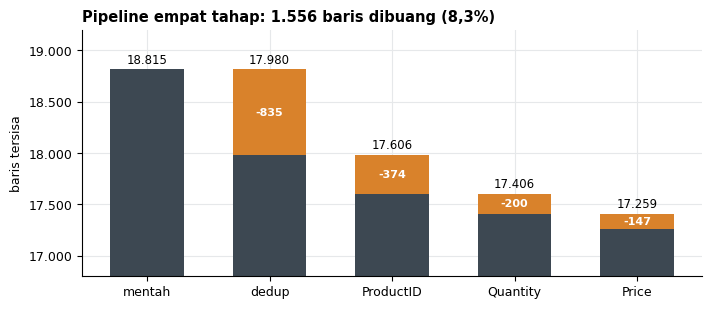

In [7]:
buang = [0] + [sisa[i-1] - sisa[i] for i in range(1, 5)]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(range(5), sisa, color=GELAP, width=.6); ax.bar(range(5), buang, bottom=sisa, color=ORANYE, width=.6)
ax.set_xticks(range(5)); ax.set_xticklabels(["mentah", "dedup", "ProductID", "Quantity", "Price"])
for i, (s, b) in enumerate(zip(sisa, buang)):
    ax.text(i, s + b + 60, ribu(s), ha="center", fontsize=8.5)
    if b: ax.text(i, s + b/2, f"-{b}", ha="center", va="center", color="white", fontsize=8, fontweight="bold")
ax.set_ylim(16800, 19200); ax.yaxis.set_major_formatter(F_RIBU); ax.set_ylabel("baris tersisa")
ax.set_title(f"Pipeline empat tahap: {ribu(sisa[0]-sisa[-1])} baris dibuang ({des((sisa[0]-sisa[-1])/sisa[0]*100,1)}%)")
plt.show()

### Kenapa angka profil (375 dan 150) berbeda dari angka pipeline (374 dan 147)

In [8]:
q("""SELECT
    (SELECT count(*) FROM order_items WHERE ProductID IS NULL)  AS pid_kosong_mentah,   -- 375
    (SELECT count(*) FROM deduped     WHERE ProductID IS NULL)  AS pid_kosong_dedup,    -- 374: selisih 1 = duplikat
    (SELECT count(*) FROM order_items WHERE Price <= 0)         AS harga_nol_mentah,    -- 150
    (SELECT count(*) FROM deduped     WHERE Price <= 0)         AS harga_nol_dedup,     -- 150: tidak ada duplikat
    (SELECT count(*) FROM deduped WHERE Price <= 0 AND Quantity <= 0
        AND ProductID IS NOT NULL)                              AS retur_sekaligus_gratis; -- 3: sudah keluar di tahap Quantity""").T.rename(columns={0: "baris"})

,baris
pid_kosong_mentah,375
pid_kosong_dedup,374
harga_nol_mentah,150
harga_nol_dedup,150
retur_sekaligus_gratis,3


- **375 menjadi 374:** satu baris `ProductID` kosong adalah duplikat, sudah keluar di tahap pertama.
- **150 menjadi 147:** **tidak ada** baris harga nol yang duplikat. Selisih 3 adalah baris yang **sekaligus retur dan harga nol**, sudah keluar di tahap `Quantity`.

## 3.3 Batas pembuangan retur dan sampel gratis

In [9]:
q("""WITH per_produk AS (
    SELECT OrderID, ProductID,
           sum(Quantity) FILTER (WHERE Quantity > 0 AND Price > 0) AS beli,
           sum(Quantity) FILTER (WHERE Quantity <= 0)              AS retur
    FROM deduped WHERE ProductID IS NOT NULL
    GROUP BY 1, 2
)
SELECT
    count(*) FILTER (WHERE beli IS NOT NULL AND retur IS NOT NULL AND beli + retur <= 0) AS dibeli_lalu_retur_penuh, -- 16
    (SELECT count(*) FROM deduped a WHERE Quantity <= 0 AND ProductID IS NOT NULL
        AND NOT EXISTS (SELECT 1 FROM deduped b WHERE b.OrderID = a.OrderID
                        AND b.ProductID = a.ProductID AND b.Quantity > 0))               AS retur_tanpa_pembelian, -- 184
    (SELECT count(*) FROM deduped a WHERE Price <= 0 AND ProductID IS NOT NULL
        AND EXISTS (SELECT 1 FROM deduped b WHERE b.OrderID = a.OrderID
                    AND b.ProductID = a.ProductID AND b.Price > 0))                      AS gratis_produk_juga_dibeli -- 20
FROM per_produk""").T.rename(columns={0: "jumlah"})

,jumlah
dibeli_lalu_retur_penuh,16
retur_tanpa_pembelian,184
gratis_produk_juga_dibeli,20


16 produk dibeli lalu diretur penuh di order yang sama tetap terhitung; 184 retur tidak tertaut ke pembeliannya; 20 sampel gratis adalah produk yang juga dibeli di order itu. Dicatat sebagai **batas B5**, dan dampaknya diuji di Langkah 5.

## 3.4 Keranjang sebagai himpunan, dan seberapa besar duplikat menggandakan (keputusan K2)

In [10]:
con.execute("CREATE OR REPLACE TABLE keranjang AS SELECT DISTINCT OrderID, ProductID FROM bersih")
n = nilai("SELECT count(DISTINCT OrderID) FROM keranjang")
print(f"Keranjang: {ribu(n)} order, {nilai('SELECT count(DISTINCT ProductID) FROM keranjang')} produk")
print(f"Baris dibuang oleh DISTINCT keranjang: {nilai('SELECT count(*) FROM bersih') - nilai('SELECT count(*) FROM keranjang')}"
      " (dedup tujuh kolom sudah menutup semuanya; DISTINCT tetap dipasang sebagai pagar)")
con.execute("""CREATE OR REPLACE TABLE tanpa_dedup AS SELECT * FROM order_items
               WHERE ProductID IS NOT NULL AND ProductID <> '' AND Quantity > 0 AND Price > 0""")
sj = lambda t: nilai(f"SELECT count(*) FROM {t} a JOIN {t} b ON a.OrderID=b.OrderID WHERE a.ProductID<b.ProductID")
p_mentah, p_tanpa_dedup, p_keranjang = sj("order_items"), sj("tanpa_dedup"), sj("keranjang")
semu = p_tanpa_dedup - p_keranjang
per_order = q("""WITH x AS (SELECT OrderID, count(*) p FROM tanpa_dedup a JOIN tanpa_dedup b USING (OrderID)
           WHERE a.ProductID < b.ProductID GROUP BY 1),
     y AS (SELECT OrderID, count(*) p FROM keranjang a JOIN keranjang b USING (OrderID)
           WHERE a.ProductID < b.ProductID GROUP BY 1),
     d AS (SELECT x.p - coalesce(y.p, 0) AS ekstra FROM x LEFT JOIN y USING (OrderID))
SELECT count(*) FILTER (WHERE ekstra > 0)  AS order_terkena,   -- 729
       median(ekstra) FILTER (WHERE ekstra > 0) AS median_ekstra, -- 6
       max(ekstra)                         AS ekstra_terbanyak -- 30
FROM d""")
print(f"\nPasangan dari tabel mentah {ribu(p_mentah)}, tanpa membuang duplikat {ribu(p_tanpa_dedup)}, keranjang bersih {ribu(p_keranjang)}")
print(f"835 baris duplikat menghasilkan {ribu(semu)} pasangan PALSU ({des(semu/p_keranjang*100,1)}%) di "
      f"{ribu(per_order.order_terkena[0])} order; median {ribu(per_order.median_ekstra[0])}, paling banyak "
      f"{ribu(per_order.ekstra_terbanyak[0])} di satu order. TIDAK MERATA.")

Keranjang: 3.000 order, 15 produk
Baris dibuang oleh DISTINCT keranjang: 0 (dedup tujuh kolom sudah menutup semuanya; DISTINCT tetap dipasang sebagai pagar)

Pasangan dari tabel mentah 53.733, tanpa membuang duplikat 51.719, keranjang bersih 47.033
835 baris duplikat menghasilkan 4.686 pasangan PALSU (10,0%) di 729 order; median 6, paling banyak 30 di satu order. TIDAK MERATA.


### Grafik kerja B · Ukuran keranjang
*Tidak masuk lampiran.* **Alasan:** grafik ini menjelaskan kenapa duplikat berbahaya, tetapi tidak menopang satu klaim memo pun. Angkanya ada di catatan keputusan bagian 1.5.

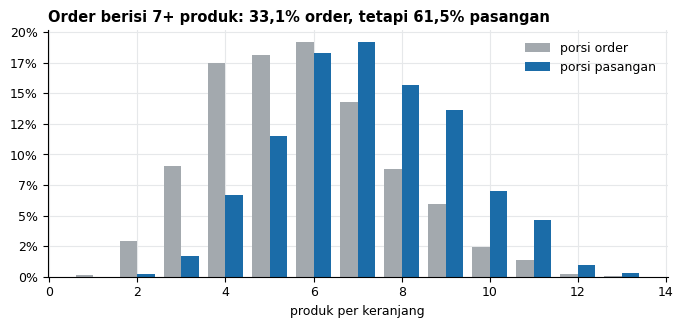

In [11]:
uk = q("""SELECT n, count(*) AS o, count(*)*n*(n-1)/2 AS p
          FROM (SELECT OrderID, count(*) n FROM keranjang GROUP BY 1) GROUP BY 1 ORDER BY 1""")
uk["po"], uk["pp"] = uk.o/uk.o.sum()*100, uk.p/uk.p.sum()*100
fig, ax = plt.subplots(figsize=(8, 3.2)); w = .4
ax.bar(uk.n - w/2, uk.po, w, color=ABU, label="porsi order"); ax.bar(uk.n + w/2, uk.pp, w, color=BIRU, label="porsi pasangan")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{int(v)}%")); ax.legend(frameon=False)
besar = uk[uk.n >= 7]
ax.set_title(f"Order berisi 7+ produk: {des(besar.po.sum(),1)}% order, tetapi {des(besar.pp.sum(),1)}% pasangan")
ax.set_xlabel("produk per keranjang"); plt.show()

## 3.5 Gerbang pembersihan

In [12]:
GERBANG = {"mentah": 18815, "dedup": 17980, "ProductID": 17606, "Quantity": 17406, "Price": 17259, "keranjang": 3000}
aktual = dict(zip(GERBANG, sisa + [n]))
for k, v in GERBANG.items(): print(f"{'OK ' if aktual[k] == v else 'XX '} {k:<10} harus {ribu(v):>7}  dapat {ribu(aktual[k]):>7}")
assert aktual == GERBANG, "Kalau berbeda, buru DEFINISINYA, bukan bug-nya."

OK  mentah     harus  18.815  dapat  18.815
OK  dedup      harus  17.980  dapat  17.980
OK  ProductID  harus  17.606  dapat  17.606
OK  Quantity   harus  17.406  dapat  17.406
OK  Price      harus  17.259  dapat  17.259
OK  keranjang  harus   3.000  dapat   3.000


---
# Langkah 4 · Analisis
## 4.1 Kueri asosiasi
Fungsi `asosiasi()` menghitung seluruh metrik untuk tabel keranjang mana pun, dan dipakai ulang di Langkah 5. **z memakai galat baku binomial** (keputusan K6).

In [13]:
con.execute("""CREATE OR REPLACE MACRO asosiasi(k) AS TABLE
WITH t AS (SELECT count(DISTINCT OrderID)::DOUBLE AS n FROM query_table(k)),
sp AS (SELECT ProductID, count(*)::DOUBLE AS op FROM query_table(k) GROUP BY 1),
p AS (
    SELECT a.ProductID AS pa, b.ProductID AS pb, count(*)::DOUBLE AS bersama
    FROM query_table(k) a JOIN query_table(k) b ON a.OrderID = b.OrderID
    WHERE a.ProductID < b.ProductID GROUP BY 1, 2
)
SELECT p.pa, p.pb, CAST(p.bersama AS BIGINT) AS bersama, t.n,
       sa.op AS order_a, sb.op AS order_b,
       p.bersama / sa.op AS conf_a_ke_b, p.bersama / sb.op AS conf_b_ke_a,
       p.bersama * t.n / (sa.op * sb.op) AS lift,
       t.n / greatest(sa.op, sb.op) AS batas_lift,
       sa.op + sb.op - 2 * p.bersama AS ruang_tumbuh,
       (p.bersama - sa.op * sb.op / t.n)
         / sqrt(t.n * (sa.op / t.n) * (sb.op / t.n) * (1 - (sa.op / t.n) * (sb.op / t.n))) AS z
FROM p CROSS JOIN t
JOIN sp sa ON sa.ProductID = p.pa
JOIN sp sb ON sb.ProductID = p.pb;

CREATE OR REPLACE TABLE metrik AS SELECT * FROM asosiasi('keranjang');""")
info = q("SELECT DISTINCT ProductID, ProductName, Category FROM bersih").set_index("ProductID")
m = q("SELECT * FROM metrik")
m["nama"] = m.pa.map(info.ProductName) + " + " + m.pb.map(info.ProductName)
m["lintas"] = m.pa.map(info.Category) != m.pb.map(info.Category)
m["persen_batas"] = m.lift / m.batas_lift * 100
m["conf_terkuat"] = m[["conf_a_ke_b", "conf_b_ke_a"]].max(axis=1) * 100
print(f"{len(m)} pasangan")

105 pasangan


## 4.2 Pemeriksaan aritmetika, sebelum satu baris pun ditafsirkan

In [14]:
cek = q("""SELECT
    (SELECT count(*) FROM metrik)                                         AS jumlah_pasangan,     -- 105, bukan 210
    (SELECT count(*) FROM metrik WHERE bersama > order_a OR bersama > order_b) AS lewat_batas_atas, -- 0
    (SELECT count(*) FROM metrik WHERE conf_a_ke_b > 1 OR conf_b_ke_a > 1)     AS conf_lebih_100,   -- 0
    (SELECT count(DISTINCT OrderID) FROM keranjang)                       AS penyebut_support,    -- 3.000
    (SELECT count(DISTINCT OrderID) FROM bersih)                          AS order_bersih,        -- 3.000
    (SELECT max(abs(lift - conf_a_ke_b / (order_b / n))) FROM metrik)     AS cek_identitas_lift,  -- ~0
    (SELECT round(min(lift), 2) FROM metrik)                              AS lift_terendah,       -- 0,89
    (SELECT round(max(lift), 2) FROM metrik)                              AS lift_tertinggi;      -- 13,46""")
display(cek.T.rename(columns={0: "hasil"}))
assert cek.jumlah_pasangan[0] == 105 and cek.lewat_batas_atas[0] == 0

,hasil
jumlah_pasangan,1.050000e+02
lewat_batas_atas,0.000000e+00
conf_lebih_100,0.000000e+00
penyebut_support,3.000000e+03
order_bersih,3.000000e+03
cek_identitas_lift,2.220446e-16
lift_terendah,8.900000e-01
lift_tertinggi,1.346000e+01


## 4.3 Tiga metrik, tiga daftar teratas yang berbeda (keputusan K4)

In [15]:
kol = ["nama", "bersama", "conf_terkuat", "lift", "z"]
for urut, judul in [("bersama", "SUPPORT"), ("conf_terkuat", "CONFIDENCE"), ("lift", "LIFT")]:
    print(f"\nDiurutkan menurut {judul}")
    print(m.sort_values(urut, ascending=False)[kol].head(5).to_string(index=False,
          formatters={"conf_terkuat": lambda v: des(v, 1) + "%", "lift": des, "z": lambda v: des(v, 1)}))


Diurutkan menurut SUPPORT
                                 nama  bersama conf_terkuat lift    z
  Daily Moisturizer + Sunscreen SPF50     1395        87,6% 1,41 15,6
        Brightening Serum + Eye Cream     1333        84,7% 1,48 17,1
          Matte Lip Cream + Lip Liner     1231        86,0% 1,68 21,1
        Daily Moisturizer + Eye Cream     1066        61,9% 0,99 -0,3
Brightening Serum + Daily Moisturizer      976        62,0% 1,00 -0,2

Diurutkan menurut CONFIDENCE
                               nama  bersama conf_terkuat  lift    z
          Eye Primer + Eyeliner Pen      146        92,4% 13,46 41,1
Daily Moisturizer + Sunscreen SPF50     1395        87,6%  1,41 15,6
        Matte Lip Cream + Lip Liner     1231        86,0%  1,68 21,1
      Brightening Serum + Eye Cream     1333        84,7%  1,48 17,1
    Daily Moisturizer + Night Cream      670        62,7%  1,01  0,2

Diurutkan menurut LIFT
                               nama  bersama conf_terkuat  lift    z
          Eye Pr

Support menaikkan dua pasangan laris yang berlift 0,99 dan 1,00; confidence dan lift menaikkan pasangan yang hanya ada di 146 keranjang. **Bundel yang layak harus lolos lebih dari satu ukuran sekaligus.**

## 4.4 Saringan tiga syarat (keputusan K8)

In [16]:
AMBANG, Z_MIN = 200, 1.96
for k, v in [("semua pasangan", len(m)), ("lift > 1", int((m.lift > 1).sum())),
             (f"+ bersama >= {AMBANG}", int(((m.lift > 1) & (m.bersama >= AMBANG)).sum())),
             (f"+ z > {des(Z_MIN)}", int(((m.lift > 1) & (m.bersama >= AMBANG) & (m.z > Z_MIN)).sum()))]:
    print(f"{k:<20} {v:>4}")
lolos = m[(m.lift > 1) & (m.bersama >= AMBANG) & (m.z > Z_MIN)].sort_values("lift", ascending=False).reset_index(drop=True)
jebakan = m.sort_values("lift", ascending=False).iloc[0]
BUNDEL = list(zip(lolos.pa, lolos.pb)); JEBAKAN = (jebakan.pa, jebakan.pb)
print(f"\nz tertinggi di antara pasangan lift > 1 yang tidak lolos uji kebetulan: {des(m[(m.lift>1)&~(m.z>Z_MIN)].z.max())}")

semua pasangan        105
lift > 1               47
+ bersama >= 200       34
+ z > 1,96              3

z tertinggi di antara pasangan lift > 1 yang tidak lolos uji kebetulan: 1,36


## 4.5 Tiga bundel yang lolos

In [17]:
display(lolos.assign(persen=lambda d: d.bersama / n * 100, conf_ab=lambda d: d.conf_a_ke_b*100,
                     conf_ba=lambda d: d.conf_b_ke_a*100)[
    ["nama", "lintas", "bersama", "persen", "lift", "batas_lift", "persen_batas", "z", "conf_ab", "conf_ba", "ruang_tumbuh"]
].style.format({"persen": "{:.1f}%", "lift": "{:.2f}", "batas_lift": "{:.2f}", "persen_batas": "{:.1f}%", "z": "{:.1f}",
                "conf_ab": "{:.1f}%", "conf_ba": "{:.1f}%", "ruang_tumbuh": "{:.0f}"}).hide(axis="index"))

nama,lintas,bersama,persen,lift,batas_lift,persen_batas,z,conf_ab,conf_ba,ruang_tumbuh
Matte Lip Cream + Lip Liner,False,1231,41.0%,1.68,1.95,86.0%,21.1,86.0%,80.1%,507
Brightening Serum + Eye Cream,True,1333,44.4%,1.48,1.74,84.7%,17.1,84.7%,77.4%,630
Daily Moisturizer + Sunscreen SPF50,False,1395,46.5%,1.41,1.61,87.6%,15.6,74.6%,87.6%,672


### Gambar 6 · Satu data, tiga cara mengurutkan
*Dipakai di portofolio PDF halaman 2 dan, dalam bentuk interaktif, di pembuka portofolio HTML. Tidak masuk lampiran karena klaimnya sudah ditopang Gambar 1 dan 2.*

Inilah pelajaran inti bagian 4.3 dalam satu gambar: empat pasangan yang sama, tiga kolom pengurut, tiga urutan yang berbeda (keputusan K4 dan K5).

**Apa yang tergambar:** empat pasangan yang sama, yaitu pasangan yang ditolak dan tiga bundel, diurutkan tiga kali: menurut kekuatan hubungan, menurut jangkauan (jumlah keranjang), dan menurut kekuatan dibanding batas maksimumnya.

**Cara membaca:** baca dari kiri ke kanan dan ikuti batang oranye. **Posisinya berpindah dari puncak, ke dasar, lalu sejajar dengan bundel lain, padahal datanya sama persis.** Panjang batang hanya bisa dibandingkan di dalam satu panel, karena satuan tiap panel berbeda.

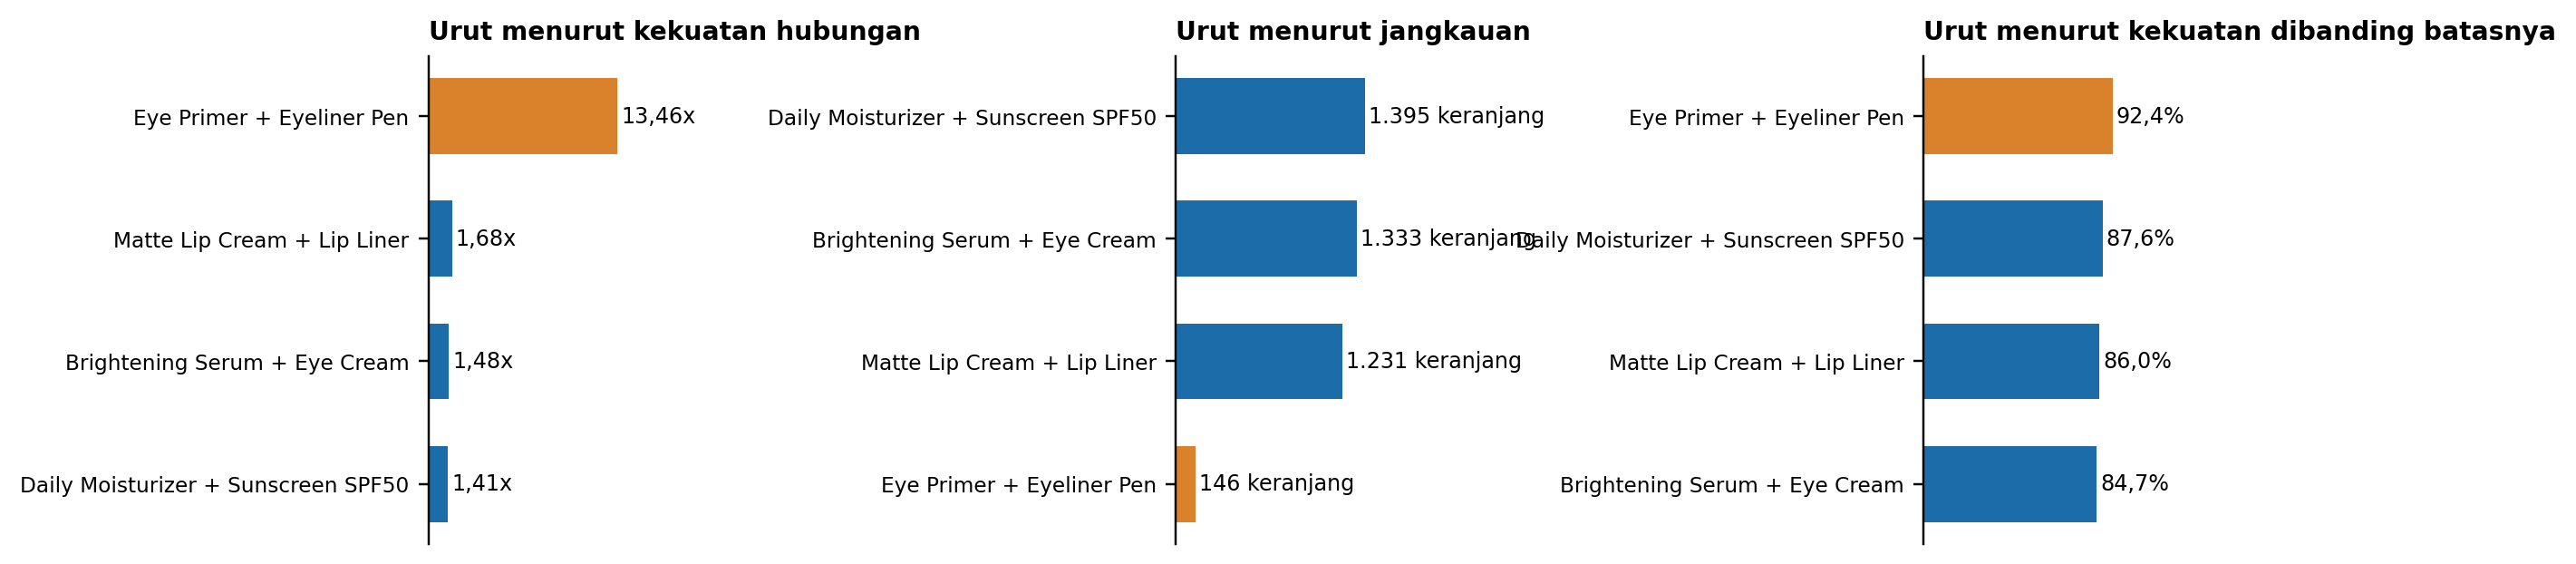

[
 {
  "nama": "Pasangan yang ditolak",
  "ditolak": true,
  "lift": 13.457048052107657,
  "keranjang": 146,
  "batas": 92.40506329113924
 },
 {
  "nama": "Bundel 1",
  "ditolak": false,
  "lift": 1.6778858910378267,
  "keranjang": 1231,
  "batas": 85.96368715083798
 },
 {
  "nama": "Bundel 2",
  "ditolak": false,
  "lift": 1.4754127392426584,
  "keranjang": 1333,
  "batas": 84.68869123252858
 },
 {
  "nama": "Bundel 3",
  "ditolak": false,
  "lift": 1.4056279529522722,
  "keranjang": 1395,
  "batas": 87.57062146892656
 }
]


In [18]:
baris_g6 = [dict(nama=r.nama, nama_anon=("Pasangan yang ditolak" if i == 0 else f"Bundel {i}"), ditolak=(i == 0),
                 lift=r.lift, keranjang=r.bersama, persen_batas=r.persen_batas)
            for i, r in enumerate([jebakan] + [x for _, x in lolos.iterrows()])]
gambar_tiga_urutan(baris_g6, anon=False, out="grafik/gambar6_tiga_urutan.png")
gambar_tiga_urutan(baris_g6, anon=True, out="grafik/gambar6_tiga_urutan_portofolio.png", data_out="grafik/gambar6_data.json")
plt.close("all"); display(Image("grafik/gambar6_tiga_urutan.png", width=860))
print(open("grafik/gambar6_data.json").read())

**Rentang data:** 3.000 keranjang dari 17.259 item bersih, lima kuartal.

**Yang terlihat:** di panel kiri batang oranye paling panjang (13,46 kali lipat); di panel tengah paling pendek (146 keranjang); di panel kanan keempat batang hampir sama panjang (84,7% sampai 92,4%).

## 4.6 Gambar 1 · Kekuatan hubungan lawan besar bukti
*Dipakai di lampiran Gambar 1 dan portofolio halaman 1.*

**Apa yang tergambar:** seluruh 105 pasangan produk yang mungkin dari 15 produk. Sumbu mendatar adalah jumlah keranjang yang memuat kedua produk; sumbu tegak adalah berapa kali lipat keduanya muncul bersama dibanding kebetulan. Garis titik tegak menandai ambang bukti 200 keranjang.

**Cara membaca:** setiap titik adalah satu pasangan. **Makin ke kanan, makin besar buktinya** dan makin banyak order yang dijangkau kampanye. **Makin ke atas, makin kuat hubungannya**; titik di garis putus-putus muncul bersama persis sesering kebetulan. **Pasangan yang layak dikampanyekan harus berada di kanan garis titik dan jelas di atas garis putus-putus.** Sumbu tegak berskala logaritmik: jarak 1 ke 2 sama dengan 5 ke 10.

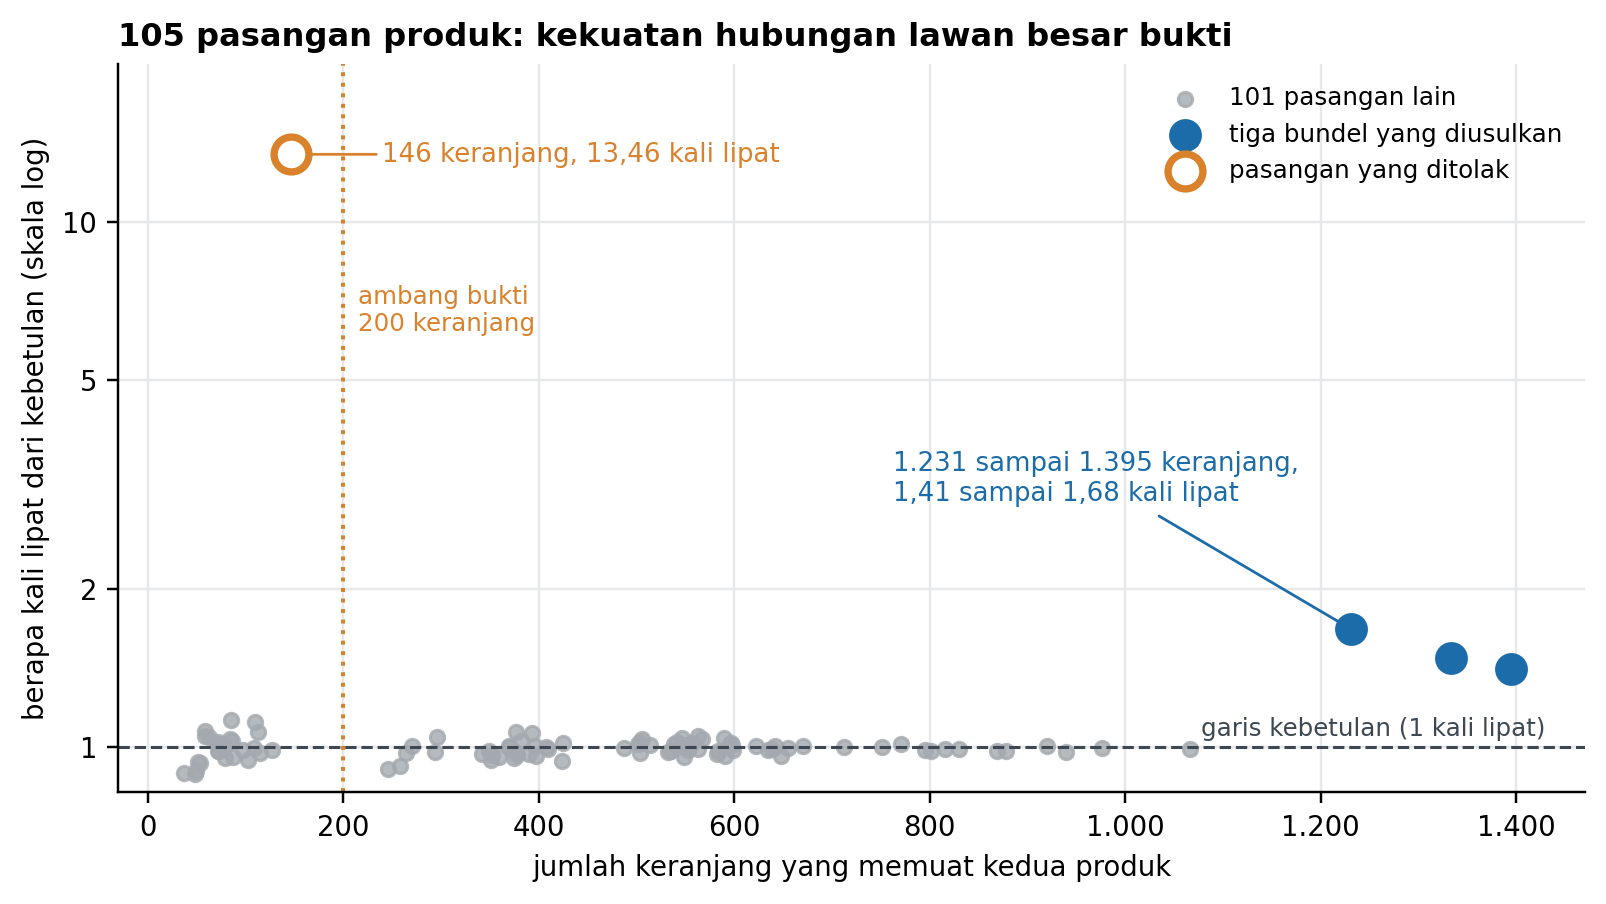

In [19]:
gambar_sebar(m, BUNDEL, JEBAKAN, anon=False, out="grafik/gambar1_sebar.png")
gambar_sebar(m, BUNDEL, JEBAKAN, anon=True, ukuran=(6.6, 4.6), out="grafik/gambar1_sebar_portofolio.png")
gambar_sebar(m, BUNDEL, JEBAKAN, anon=True, out="grafik/gambar1_sebar_portofolio_lebar.png")  # versi lebar untuk portofolio HTML
plt.close("all"); display(Image("grafik/gambar1_sebar.png", width=760))

**Rentang data:** 3.000 keranjang dari 17.259 item bersih, Januari 2025 sampai Maret 2026.

**Yang terlihat:** satu lingkaran oranye berdiri sendirian di kiri atas, di kiri garis ambang; tiga titik biru duduk berdekatan di kanan bawah; 101 titik abu-abu menumpuk di sekitar garis putus-putus.

## 4.7 Gambar 2 · Batas maksimum lift dan ruang tumbuh (keputusan K5, rekomendasi R3 dan R4)
*Dipakai di lampiran Gambar 2 dan portofolio halaman 2.*

Lift sebuah pasangan **tidak bisa melebihi** jumlah keranjang dibagi jumlah keranjang produk yang lebih populer.

**Apa yang tergambar:** kiri, lift tiap pasangan sebagai persentase dari lift tertinggi yang mungkin dicapainya; batas ini ditentukan oleh produk yang lebih populer di pasangannya. Kanan, jumlah keranjang yang memuat salah satu produk bundel saja.

**Cara membaca:** di panel kiri, batang abu-abu muda adalah 100%, yaitu batas maksimum pasangan itu, dan batang berwarna menunjukkan seberapa dekat pasangan itu ke batasnya. **Bandingkan panjang batang, bukan angka lift di sebelahnya**: batang yang hampir sama panjang berarti hampir sama kuat, meski angka lift-nya sangat berbeda. Di panel kanan, **makin panjang batang, makin besar ruang tumbuh**, yaitu makin banyak keranjang yang baru berisi salah satu produk.

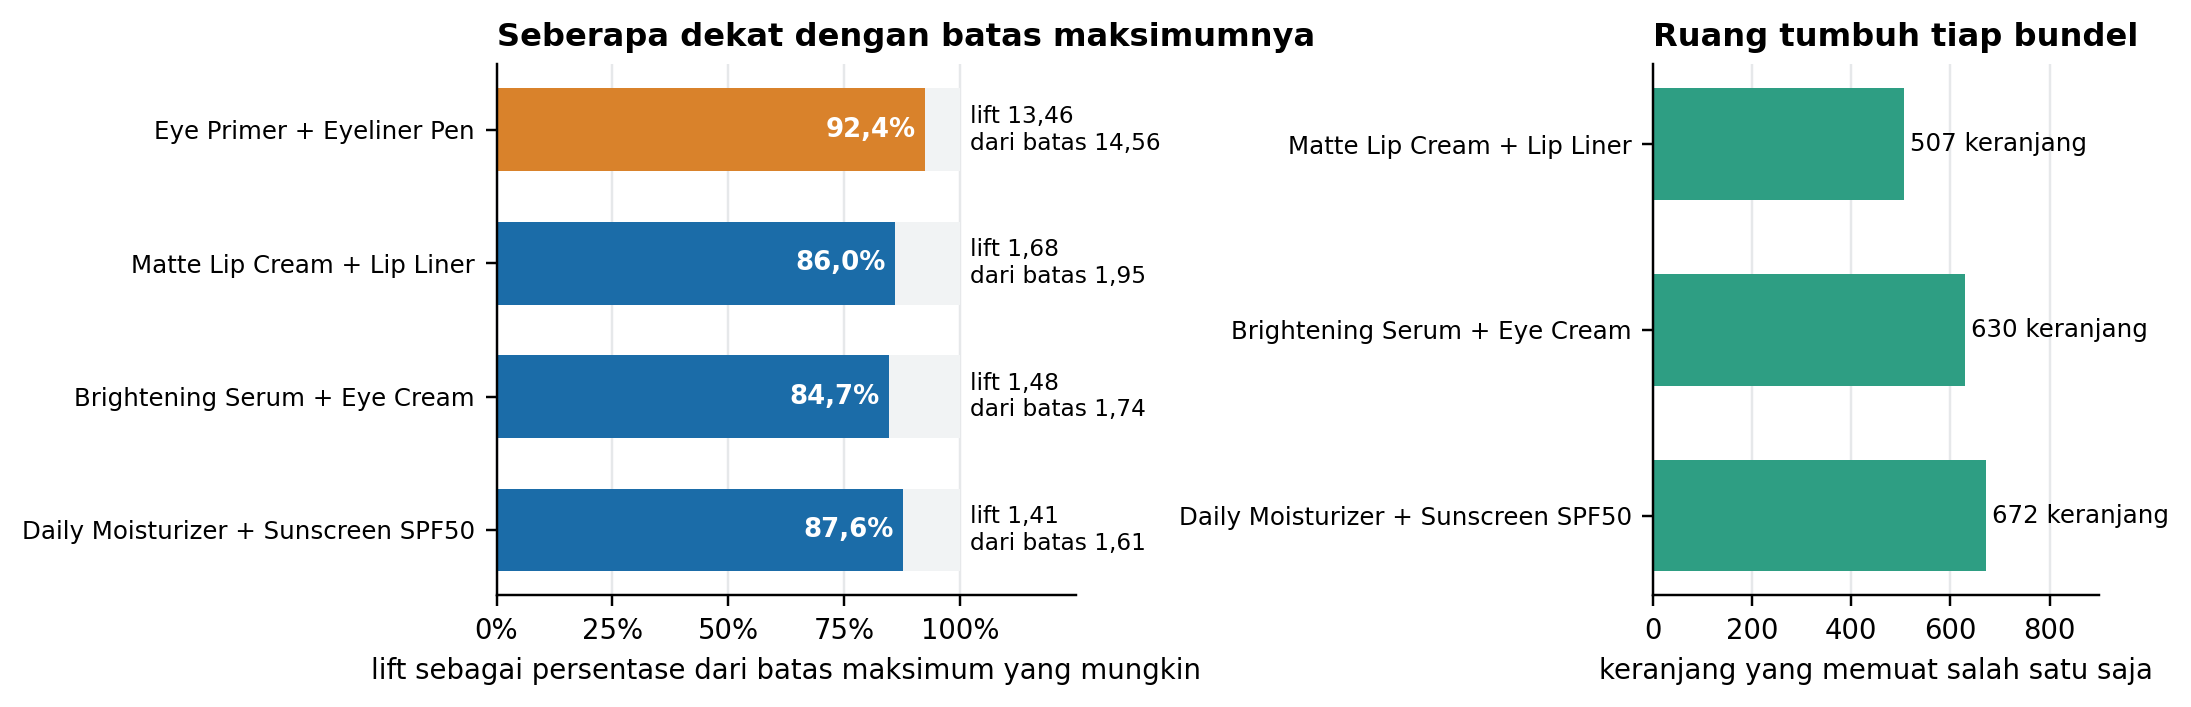

Korelasi lift dengan batasnya di seluruh 105 pasangan: 0,91
Confidence pasangan yang ditolak: 92,4% dari arah Eye Primer, hanya 70,9% dari arah Eyeliner Pen.


In [20]:
utama = [jebakan] + [r for _, r in lolos.iterrows()]
baris_g2 = [dict(nama=r.nama, nama_anon=("pasangan yang ditolak" if i == 0 else f"bundel {i}"), lift=r.lift,
                 batas=r.batas_lift, persen=r.persen_batas, ruang=r.ruang_tumbuh, ditolak=(i == 0))
            for i, r in enumerate(utama)]
gambar_batas_ruang(baris_g2, anon=False, out="grafik/gambar2_batas_ruang.png")
gambar_batas_ruang(baris_g2, anon=True, out="grafik/gambar2_batas_ruang_portofolio.png")
plt.close("all"); display(Image("grafik/gambar2_batas_ruang.png", width=820))
print(f"Korelasi lift dengan batasnya di seluruh 105 pasangan: {des(m.lift.corr(m.batas_lift))}")
print(f"Confidence pasangan yang ditolak: {des(jebakan.conf_a_ke_b*100,1)}% dari arah Eye Primer, "
      f"hanya {des(jebakan.conf_b_ke_a*100,1)}% dari arah Eyeliner Pen.")

**Rentang data:** 3.000 keranjang dari 17.259 item bersih, lima kuartal.

**Yang terlihat:** di panel kiri, keempat batang berhenti di antara 84,7% dan 92,4%; batang oranye hanya 4,8 poin lebih panjang dari batang biru terpanjang, padahal angka batasnya (14,56) 7,5 sampai 9,1 kali angka batas batang biru. Di panel kanan, batang Matte Lip Cream + Lip Liner paling pendek (507), dua lainnya 630 dan 672.

Pasangan yang ditolak tampak 8 kali lebih kuat dari bundel terbaik hanya karena batas maksimumnya jauh lebih tinggi. **Diukur terhadap batasnya, keempat pasangan sama kuat.**

### Grafik kerja C · Popularitas lima belas produk
*Tidak masuk lampiran.* **Alasan:** menjelaskan kenapa batas pasangan yang ditolak setinggi itu (kedua produknya paling jarang), tetapi isinya sudah tercakup oleh angka batas di Gambar 2. Datanya ada di catatan keputusan bagian 5.2.

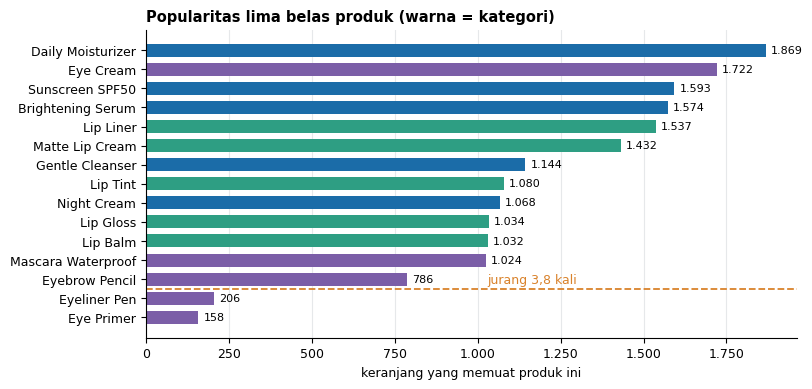

In [21]:
prod = q("SELECT ProductID, count(*) n FROM keranjang GROUP BY 1 ORDER BY n DESC")
prod["nama"] = prod.ProductID.map(info.ProductName); prod["kat"] = prod.ProductID.map(info.Category)
warna_kat = {"Face Care": BIRU, "Lip Care": HIJAU, "Eye Care": "#7b5ea7"}
fig, ax = plt.subplots(figsize=(8.4, 4))
ax.barh(prod.nama[::-1], prod.n[::-1], color=[warna_kat[k] for k in prod.kat[::-1]], height=.68)
for y, v in enumerate(prod.n[::-1]): ax.text(v + 15, y, ribu(v), va="center", fontsize=8)
ax.axhline(1.5, color=ORANYE, ls="--", lw=1.3)
ax.text(prod.n.max()*.55, 1.75, f"jurang {des(prod.n.iloc[-3]/prod.n.iloc[-2],1)} kali", color=ORANYE, fontsize=9)
ax.xaxis.set_major_formatter(F_RIBU); ax.set_xlabel("keranjang yang memuat produk ini")
ax.set_title("Popularitas lima belas produk (warna = kategori)"); ax.grid(axis="y", visible=False); plt.show()

### Grafik kerja D · Confidence dua arah ketiga bundel
*Tidak masuk lampiran.* **Alasan:** berguna untuk memutuskan bundel dipajang di halaman produk mana, tetapi tidak ada klaim memo yang bergantung padanya. Angkanya ada di catatan keputusan bagian 3 dan 5.1.

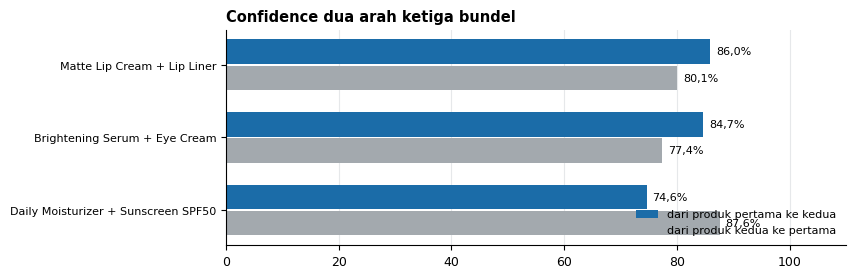

In [22]:
fig, ax = plt.subplots(figsize=(8, 2.8)); y = np.arange(len(lolos))[::-1]
ax.barh(y + .18, lolos.conf_a_ke_b*100, .34, color=BIRU, label="dari produk pertama ke kedua")
ax.barh(y - .18, lolos.conf_b_ke_a*100, .34, color=ABU, label="dari produk kedua ke pertama")
for yy, a, b in zip(y, lolos.conf_a_ke_b*100, lolos.conf_b_ke_a*100):
    ax.text(a + 1, yy + .18, f"{des(a,1)}%", va="center", fontsize=8); ax.text(b + 1, yy - .18, f"{des(b,1)}%", va="center", fontsize=8)
ax.set_yticks(y); ax.set_yticklabels(lolos.nama, fontsize=8); ax.set_xlim(0, 110)
ax.legend(frameon=False, fontsize=8, loc="lower right"); ax.set_title("Confidence dua arah ketiga bundel")
ax.grid(axis="y", visible=False); plt.show()

## 4.8 Gambar 5 · Ambang bukti digeser (keputusan K7, batas B4)
*Dipakai di lampiran Gambar 5.* Ambang adalah satu-satunya angka yang sepenuhnya milik analis, jadi ia diuji dengan digeser dari 0 sampai 1.300.

**Apa yang tergambar:** jumlah pasangan yang lolos pada dua belas ambang bukti berbeda, dari 0 sampai 1.300 keranjang. Kiri dengan saringan lift di atas 1 saja; kanan dengan ketiga syarat.

**Cara membaca:** tiap batang adalah jumlah pasangan yang lolos pada satu ambang; batang biru adalah ambang yang dipakai (200). **Bandingkan kedua panel**: di panel kiri batangnya turun tajam, di panel kanan hampir rata. **Rentang yang hasilnya tidak berubah adalah rentang tempat batang panel kanan setinggi batang biru.**

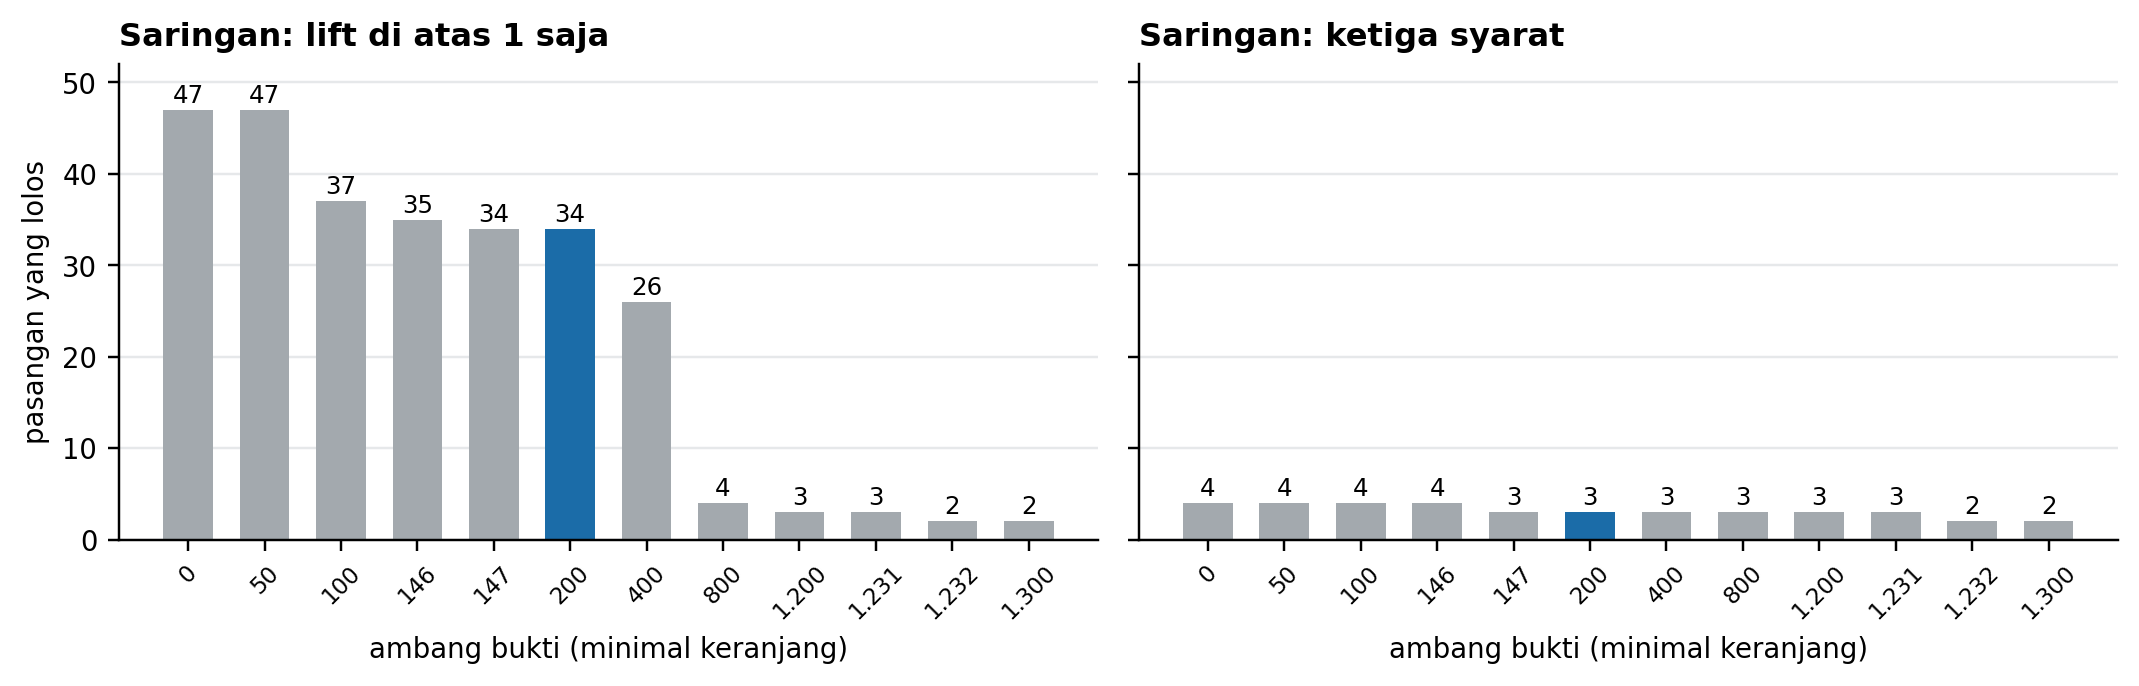

ambang,lift_saja,tiga_syarat
0,47,4
50,47,4
100,37,4
146,35,4
147,34,3
200,34,3
400,26,3
800,4,3
1200,3,3
1231,3,3


In [23]:
sens = pd.DataFrame([{"ambang": a, "lift_saja": int(((m.lift > 1) & (m.bersama >= a)).sum()),
                      "tiga_syarat": int(((m.lift > 1) & (m.bersama >= a) & (m.z > Z_MIN)).sum())}
                     for a in [0, 50, 100, 146, 147, 200, 400, 800, 1200, 1231, 1232, 1300]])
gambar_ambang(sens, 200, out="grafik/gambar5_ambang.png"); plt.close("all")
display(Image("grafik/gambar5_ambang.png", width=820))
display(sens.style.hide(axis="index"))

**Rentang data:** 3.000 keranjang, 105 pasangan, lima kuartal.

**Yang terlihat:** di panel kiri, batang turun dari 47 ke 2. Di panel kanan, batang hanya berubah di dua titik: dari 4 ke 3 di ambang 147, dan dari 3 ke 2 di ambang 1.232. Di antara 147 dan 1.231, batangnya setinggi batang biru.

Di ambang 147 pasangan yang ditolak keluar; di ambang 1.232 satu bundel ikut keluar. **Di antara keduanya hasilnya tetap tiga bundel yang sama.**

## 4.9 Pasangan yang ditolak (rekomendasi R3)
- **Hubungannya nyata:** z-nya tertinggi di seluruh tabel. Uji kebetulan tidak akan menyingkirkannya.
- **Diukur terhadap batas maksimumnya, ia sama kuat dengan ketiga bundel.**
- **Yang membedakan adalah jangkauan: 146 dari 3.000 keranjang**, kurang dari seperdelapan bundel terkecil, dengan biaya kampanye yang sama.

---
# Langkah 5 · Temuan dan bantahannya
## 5.1 Gerbang angka lengkap

In [24]:
G = {"mentah": 18815, "dedup": 17980, "ProductID": 17606, "Quantity": 17406, "Price": 17259,
     "keranjang": 3000, "pasangan": 105, "lift > 1": 47, "lolos tiga syarat": 3}
A_ = dict(zip(list(G)[:6], sisa + [n])); A_.update({"pasangan": len(m), "lift > 1": int((m.lift > 1).sum()), "lolos tiga syarat": len(lolos)})
for k, v in G.items(): print(f"{'OK ' if A_[k]==v else 'XX '} {k:<18} harus {ribu(v):>7}  dapat {ribu(A_[k]):>7}")
assert A_ == G

OK  mentah             harus  18.815  dapat  18.815
OK  dedup              harus  17.980  dapat  17.980
OK  ProductID          harus  17.606  dapat  17.606
OK  Quantity           harus  17.406  dapat  17.406
OK  Price              harus  17.259  dapat  17.259
OK  keranjang          harus   3.000  dapat   3.000
OK  pasangan           harus     105  dapat     105
OK  lift > 1           harus      47  dapat      47
OK  lolos tiga syarat  harus       3  dapat       3


## 5.2 Gambar 3 · Bantahan "bundel lintas kategori cuma efek keranjang besar" (keputusan K9)
*Dipakai di lampiran Gambar 3.* Kalau bantahan ini benar, **seluruh** pasangan lintas kategori akan ikut terangkat.

**Apa yang tergambar:** lift tiap pasangan, dikelompokkan menjadi pasangan dua kategori berbeda (75 pasangan) dan pasangan satu kategori (30 pasangan), pada skala logaritmik.

**Cara membaca:** setiap titik adalah satu pasangan. Garis gelap mendatar adalah median kelompok. Titik biru adalah hubungan nyata (lift di atas 1 dan z di atas 1,96); lingkaran oranye adalah pasangan yang ditolak. **Kalau ukuran keranjang yang menjelaskan hubungan lintas kategori, seluruh kolom kiri akan terangkat, bukan hanya satu titik.**

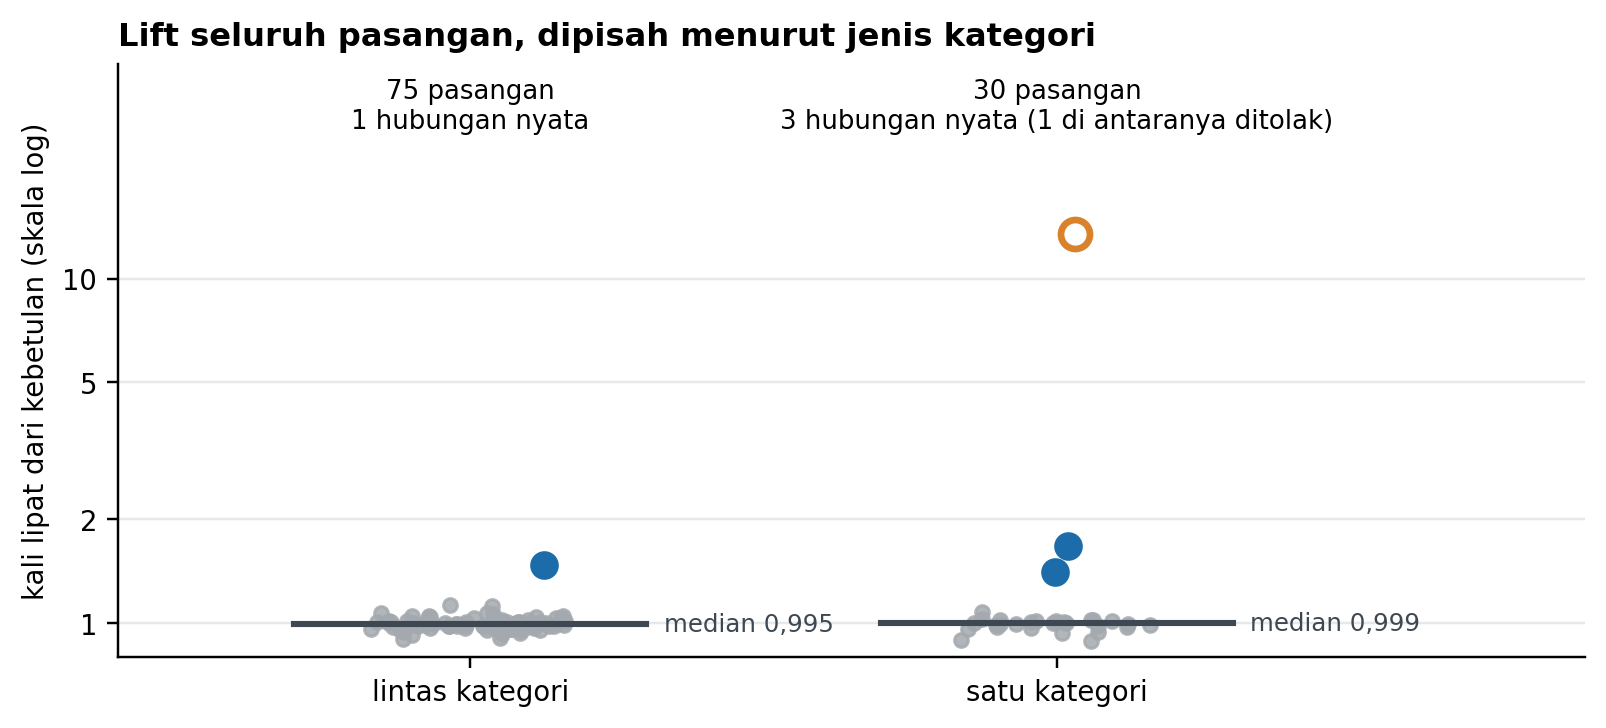

,pasangan,rata_rata,median,rata_rata_tanpa_yang_ditolak,lift_di_atas_1,hubungan_nyata
lintas,,,,,,
satu kategori,30,1.442,0.999,1.027,14,3
lintas kategori,75,1.004,0.995,1.004,33,1


In [25]:
gambar_kategori(m, JEBAKAN, out="grafik/gambar3_kategori.png"); plt.close("all")
display(Image("grafik/gambar3_kategori.png", width=760))
kat = m.assign(ditolak=[(a, b) == JEBAKAN for a, b in zip(m.pa, m.pb)]).groupby("lintas").apply(lambda g: pd.Series({
    "pasangan": len(g), "rata_rata": g.lift.mean(), "median": g.lift.median(),
    "rata_rata_tanpa_yang_ditolak": g[~g.ditolak].lift.mean(),
    "lift_di_atas_1": int((g.lift > 1).sum()), "hubungan_nyata": int(((g.lift > 1) & (g.z > Z_MIN)).sum())}),
    include_groups=False).rename(index={True: "lintas kategori", False: "satu kategori"})
display(kat.style.format("{:.3f}", subset=["rata_rata", "median", "rata_rata_tanpa_yang_ditolak"]).format(
    "{:.0f}", subset=["pasangan", "lift_di_atas_1", "hubungan_nyata"]))

**Rentang data:** 3.000 keranjang dari 17.259 item bersih, lima kuartal.

**Yang terlihat:** garis median kedua kelompok berada di dekat angka 1 (0,995 dan 0,999). Di kolom kiri, satu titik biru berada di atas kerumunan abu-abu. Di kolom kanan, dua titik biru dan satu lingkaran oranye berada di atas kerumunannya.

**Bantahan ini gugur.**

Rata-rata satu kategori (1,442) **ditarik oleh satu pencilan**, yaitu pasangan yang ditolak; tanpa pencilan itu 1,027. Kesimpulan yang tepat: hubungan nyata lebih sering di dalam kategori (3 dari 30, termasuk yang ditolak) daripada lintas kategori (1 dari 75), tetapi pasangan tipikal di kedua kelompok sama-sama kebetulan.

## 5.3 Gambar 4 · Dua belas cara menghitung ulang (keputusan K10, batas B5 dan B6)
*Dipakai di lampiran Gambar 4 dan portofolio halaman 2.* Dua belas cara itu adalah data penuh, enam bulan terakhir, lima kuartal yang dihitung terpisah, dan lima cara membersihkan data yang berbeda (ProductID dipulihkan dari nama produk, retur dibiarkan, sampel gratis dibiarkan, keduanya dibiarkan, dan keranjang neto). Ambang tiap baris sebanding dengan jumlah keranjangnya.

**Apa yang tergambar:** rantai analisis yang sama dijalankan dua belas kali: data penuh, enam bulan terakhir, lima kuartal yang dihitung terpisah, dan lima cara membersihkan data yang berbeda (ProductID dipulihkan dari nama produk, retur dibiarkan, sampel gratis dibiarkan, keduanya dibiarkan, dan keranjang neto). Ambang tiap baris adalah 200 dikali porsi keranjang periodenya.

**Cara membaca:** setiap baris adalah satu cara menghitung ulang, setiap kolom satu pasangan. Di tiap sel, angka pertama adalah jumlah keranjang penopang dan angka kedua kali lipat dari kebetulan. **Biru berarti lolos ketiga syarat di baris itu, oranye berarti tidak.** Baca per kolom dari atas ke bawah: **kolom yang warnanya tidak pernah berubah adalah hasil yang kokoh.** Untuk melihat kenapa pasangan yang ditolak selalu gagal, bandingkan angka pertamanya dengan angka ambang di baris yang sama.

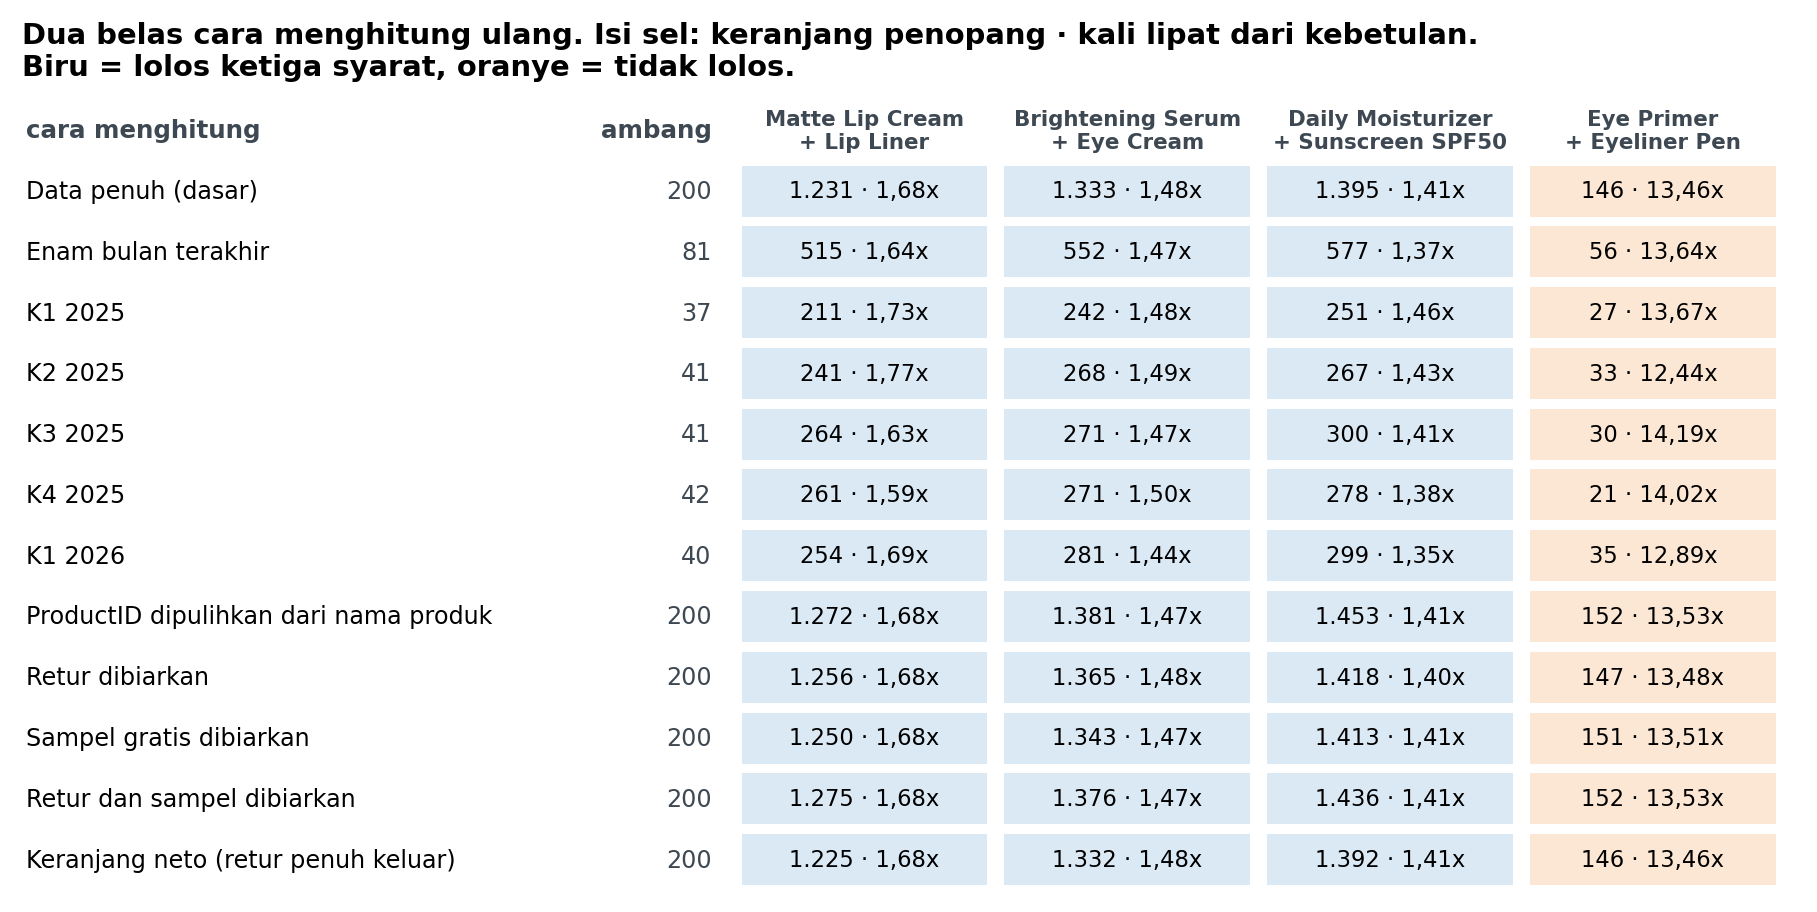

Di kedua belas cara, tiga bundel yang sama lolos dan pasangan yang ditolak tidak pernah lolos.


In [26]:
def jalankan(label, filter_tgl="", qty=True, price=True, pulih=False, neto=False):
    src = "order_items"
    if pulih:
        src = """(SELECT o.OrderID, coalesce(o.ProductID, pm.ProductID) ProductID, o.ProductName, o.Category,
                  o.Quantity, o.Price, o.OrderDate FROM order_items o LEFT JOIN
                  (SELECT DISTINCT ProductName, ProductID FROM order_items WHERE ProductID IS NOT NULL) pm USING (ProductName))"""
    if neto:
        con.execute(f"""CREATE OR REPLACE TABLE ks AS SELECT OrderID, ProductID FROM
            (SELECT DISTINCT * FROM {src} WHERE 1=1 {filter_tgl}) WHERE ProductID IS NOT NULL AND (Price > 0 OR Quantity < 0)
            GROUP BY 1, 2 HAVING sum(CASE WHEN Quantity > 0 AND Price > 0 THEN Quantity
                                          WHEN Quantity < 0 THEN Quantity ELSE 0 END) > 0""")
    else:
        w = ["ProductID IS NOT NULL", "ProductID <> ''"] + (["Quantity > 0"] if qty else []) + (["Price > 0"] if price else [])
        con.execute(f"""CREATE OR REPLACE TABLE ks AS SELECT DISTINCT OrderID, ProductID FROM
            (SELECT DISTINCT * FROM {src} WHERE 1=1 {filter_tgl}) WHERE {' AND '.join(w)}""")
    mm = q("SELECT * FROM asosiasi('ks')")
    nn = int(mm.n.iloc[0]); amb = round(AMBANG * nn / n)
    lulus = mm[(mm.lift > 1) & (mm.bersama >= amb) & (mm.z > Z_MIN)]
    ok = set(zip(lulus.pa, lulus.pb))
    sel = {}
    for k in BUNDEL + [JEBAKAN]:
        x = mm[(mm.pa == k[0]) & (mm.pb == k[1])].iloc[0]; sel[k] = (int(x.bersama), x.lift, k in ok)
    return dict(label=label, ambang=amb, keranjang=nn, sel=sel, sama=(ok == set(BUNDEL)), lift_gt1=int((mm.lift > 1).sum()))

kuartal = [("2025-01-01", "2025-04-01", "K1 2025"), ("2025-04-01", "2025-07-01", "K2 2025"),
           ("2025-07-01", "2025-10-01", "K3 2025"), ("2025-10-01", "2026-01-01", "K4 2025"),
           ("2026-01-01", "2026-04-01", "K1 2026")]
tabel12 = [jalankan("Data penuh (dasar)"), jalankan("Enam bulan terakhir", "AND OrderDate >= DATE '2025-10-01'")]
tabel12 += [jalankan(lab, f"AND OrderDate >= DATE '{a}' AND OrderDate < DATE '{b}'") for a, b, lab in kuartal]
tabel12 += [jalankan("ProductID dipulihkan dari nama produk", pulih=True), jalankan("Retur dibiarkan", qty=False),
            jalankan("Sampel gratis dibiarkan", price=False), jalankan("Retur dan sampel dibiarkan", qty=False, price=False),
            jalankan("Keranjang neto (retur penuh keluar)", neto=True)]
assert all(r["sama"] for r in tabel12) and all(not r["sel"][JEBAKAN][2] for r in tabel12)

kolom12 = [(k, nama, f"bundel {i}") for i, (k, nama) in enumerate(zip(BUNDEL, lolos.nama), 1)] + [(JEBAKAN, jebakan.nama, "pasangan yang ditolak")]
gambar_dua_belas(tabel12, kolom12, anon=False, out="grafik/gambar4_dua_belas.png")
gambar_dua_belas(tabel12, kolom12, anon=True, out="grafik/gambar4_dua_belas_portofolio.png")
plt.close("all"); display(Image("grafik/gambar4_dua_belas.png", width=860))
print("Di kedua belas cara, tiga bundel yang sama lolos dan pasangan yang ditolak tidak pernah lolos.")

**Rentang data:** 3.000 keranjang untuk data penuh, 1.218 untuk enam bulan, 551 sampai 625 per kuartal.

**Yang terlihat:** ketiga kolom bundel berwarna biru di kedua belas baris; kolom pasangan yang ditolak berwarna oranye di kedua belas baris, dan angka keranjangnya (21 sampai 152) tidak pernah mencapai ambang di barisnya.

## 5.4 Jawaban untuk Mbak Dian: enam bulan terakhir

In [27]:
d6 = tabel12[1]
print(f"Keranjang enam bulan: {ribu(d6['keranjang'])} dari {ribu(n)}; ambang diturunkan sebanding menjadi {d6['ambang']}")
for (k, nama, _), r in zip(kolom12, lolos.itertuples()):
    b6, l6, _ = d6["sel"][k]; print(f"  {nama:<38} enam bulan {ribu(b6)} · {des(l6)}x   penuh {ribu(r.bersama)} · {des(r.lift)}x")
bj, lj, _ = d6["sel"][JEBAKAN]
print(f"  Pasangan yang ditolak: {bj} keranjang, lift {des(lj)}; tetap di bawah ambang {d6['ambang']}")
print(f"  Pasangan lift > 1: {int((m.lift>1).sum())} menjadi {d6['lift_gt1']}")

Keranjang enam bulan: 1.218 dari 3.000; ambang diturunkan sebanding menjadi 81
  Matte Lip Cream + Lip Liner            enam bulan 515 · 1,64x   penuh 1.231 · 1,68x
  Brightening Serum + Eye Cream          enam bulan 552 · 1,47x   penuh 1.333 · 1,48x
  Daily Moisturizer + Sunscreen SPF50    enam bulan 577 · 1,37x   penuh 1.395 · 1,41x
  Pasangan yang ditolak: 56 keranjang, lift 13,64; tetap di bawah ambang 81
  Pasangan lift > 1: 47 menjadi 56


**Rekomendasinya tidak berubah:** bundel yang sama, urutan yang sama. Porsi keranjang ketiga bundel naik tipis dan lift-nya turun tipis. Pasangan berlift di atas 1 naik dari 47 ke 56: derau membesar ketika keranjang mengecil, alasan syarat z dipertahankan (batas B8).

---
# Langkah 6 · Keputusan, rekomendasi, dan batas, masing-masing dengan alasannya
Tabel-tabel di bawah **sama kata per kata** dengan catatan keputusan (bagian 2, 8, 9) dan lapisan bukti portofolio. Memo dan halaman depan portofolio memakai versi singkat dengan **nomor yang sama**, sehingga setiap kalimat singkat bisa ditelusuri ke baris lengkapnya di sini.

## 6.1 Keputusan analisis
| No | Keputusan | Alasan | Yang ditolak, dan alasannya |
|---|---|---|---|
| K1 | **Empat jenis baris dibuang: duplikat persis, ProductID kosong, retur, dan sampel gratis.** | Pertanyaan bisnisnya adalah produk apa yang dipilih bersama dalam satu keputusan belanja. Keempat jenis baris itu bukan pilihan belanja: salinan, tanpa identitas produk, dibatalkan pembelinya, atau diberikan penjual. | Menghitung semua baris apa adanya, karena 835 duplikat saja menciptakan 4.686 pasangan palsu. |
| K2 | **Keranjang dibentuk sebagai himpunan produk unik per order.** | Yang ditanyakan adalah produk apa yang muncul bersama, bukan berapa banyak yang dibeli. Di self-join, baris ganda mengalikan hitungan pasangan, bukan menambah. | Keranjang dari daftar baris, karena satu kejadian belanja bisa terhitung berkali-kali. |
| K3 | **Seluruh pembersihan selesai sebelum self-join.** | Begitu pasangan terbentuk, asal barisnya hilang. Tidak ada cara lagi untuk menyaring pasangan yang berasal dari retur atau sampel gratis. | Membersihkan sesudah keranjang dibentuk. |
| K4 | **Support, confidence dua arah, dan lift ditampilkan berdampingan, selalu dengan jumlah keranjang di sebelah rasionya.** | Tiap metrik buta terhadap hal yang berbeda: support tidak tahu apakah hubungannya nyata, lift dan confidence tidak tahu seberapa besar buktinya. | Mengurutkan dengan satu metrik lalu mengambil sepuluh teratas, karena support menaikkan dua pasangan laris yang berlift 0,99 dan 1,00, sedangkan lift menaikkan pasangan yang hanya ada di 146 keranjang. |
| K5 | **Kekuatan hubungan dibandingkan terhadap batas maksimumnya.** | Lift tertinggi yang mungkin dicapai sebuah pasangan ditentukan oleh produk yang lebih populer. Lift dan batasnya bergerak bersama di seluruh 105 pasangan (korelasi 0,91), jadi lift pasangan produk jarang tidak bisa dibandingkan langsung dengan pasangan produk laris. | Membaca lift 13,46 sebagai "delapan kali lebih kuat" dari bundel terbaik. |
| K6 | **Uji kebetulan memakai z dengan galat baku binomial.** | Peluang kemunculan bersama ketiga bundel sekitar 20% sampai 30%, terlalu besar untuk rumus Poisson yang dibuat untuk peluang kecil. Rumus binomial juga yang mereproduksi nilai z di modul halaman 07. | Rumus Poisson. Daftar yang lolos tetap sama, karena z tertinggi di antara pasangan yang tidak lolos hanya 1,36. |
| K7 | **Ambang bukti 200 keranjang.** | Tiap bundel memakan porsi anggaran yang sama besar entah berhasil atau tidak, jadi bundel berjangkauan kecil membayar harga penuh. Hasilnya tidak berubah untuk ambang mana pun antara 200 dan 1.200. | Ambang berbentuk persentase (jumlah keranjang lebih mudah diterjemahkan ke jangkauan kampanye) dan ambang yang disembunyikan di LIMIT 10. |
| K8 | **Saringan memakai tiga syarat sekaligus: lift di atas 1, minimal 200 keranjang, dan z di atas 1,96.** | Tiap syarat menutup lubang yang ditinggalkan dua lainnya: pasangan laris tanpa hubungan, hubungan nyata yang terlalu kecil, dan lift di atas 1 yang lahir dari kebetulan. | Menyaring dengan lift di atas 1 saja, karena 47 dari 105 pasangan lolos, kira-kira separuh, persis yang diharapkan kalau tidak ada hubungan sama sekali. |
| K9 | **Lintas kategori dilaporkan sebagai kolom, bukan dipakai sebagai saringan.** | Dua dari tiga bundel yang layak justru satu kategori. | Menyaring hanya pasangan lintas kategori, karena akan membuang dua bundel yang layak. |
| K10 | **Pada potongan enam bulan, ambang diturunkan sebanding menjadi 81 keranjang.** | Keranjangnya tinggal 1.218 (40,6%). Memakai 200 apa adanya berarti menaikkan syaratnya diam-diam. | Memakai ambang 200 apa adanya pada potongan yang lebih kecil. |

## 6.2 Rekomendasi
| No | Rekomendasi | Alasan |
|---|---|---|
| R1 | **Pasang tiga bundel: Matte Lip Cream + Lip Liner, Brightening Serum + Eye Cream, dan Daily Moisturizer + Sunscreen SPF50.** | Hanya ketiganya yang lolos ketiga syarat dari 105 pasangan. Jangkauannya 1.231 sampai 1.395 dari 3.000 keranjang, kekuatannya 1,41 sampai 1,68 kali lipat dari kebetulan, dan hasilnya sama di dua belas cara menghitung ulang. Ketiganya juga masuk akal secara pemakaian: kedua produknya dipakai dalam rutinitas perawatan yang sama. |
| R2 | **Jalankan ketiganya sebagai uji dengan kelompok pembanding, bukan langsung penuh: sebagian pembeli melihat bundel, sebagian tidak.** | Data hanya menunjukkan apa yang sudah dibeli bersama, bukan apa yang akan dibeli karena dibundel. Tanpa kelompok pembanding, kenaikan penjualan tidak bisa dibedakan dari pembelian yang memang sudah terjadi. Kalau selisihnya nol, itu diketahui setelah menghabiskan sebagian kecil anggaran, bukan seluruhnya. |
| R3 | **Jangan kampanyekan Eye Primer + Eyeliner Pen; pasang di rekomendasi otomatis halaman produk.** | Hubungannya nyata dan, diukur terhadap batas maksimumnya, sama kuat dengan ketiga bundel (92,4% lawan 84,7% sampai 87,6%). Tetapi ia hanya menyentuh 146 dari 3.000 keranjang, kurang dari seperdelapan bundel terkecil, dengan biaya kampanye yang sama. Di kanal yang biayanya nyaris nol per pasangan, hubungan kuat pada kelompok kecil justru berguna. |
| R4 | **Kalau anggaran hanya cukup untuk dua uji: jalankan Brightening Serum + Eye Cream dan Daily Moisturizer + Sunscreen SPF50, tunda Matte Lip Cream + Lip Liner.** | Matte Lip Cream + Lip Liner punya ruang tumbuh paling kecil: hanya 507 keranjang yang baru memuat salah satu produknya, dibanding 630 dan 672. Diskonnya paling mungkin hanya membiayai pembelian yang sudah terjadi. Brightening Serum + Eye Cream didahulukan karena ia satu-satunya hubungan nyata di antara 75 pasangan lintas kategori, sehingga hasil ujinya paling sedikit bisa ditebak dari pasangan lain. |

## 6.3 Batas
| No | Batas | Kenapa ini batas | Akibatnya, dan yang dilakukan |
|---|---|---|---|
| B1 | **Penjualan tambahan dari bundel tidak bisa diperkirakan.** | Data tidak memuat hasil kampanye maupun percobaan promosi apa pun. | Tidak ada klaim kenaikan penjualan, uplift, conversion, atau ROI, termasuk klaim bahwa bundel lintas kategori memindahkan pembeli ke kategori baru. Rekomendasi dibuat berbentuk uji (R2). |
| B2 | **Semua persentase adalah persentase keranjang, bukan persentase orang.** | Data tidak punya ID pelanggan, dan satu orang bisa punya banyak order. | Setiap angka ditulis bersama penyebutnya, misalnya "dari 3.000 keranjang". |
| B3 | **Margin bundel tidak dinilai.** | Harga pokok tidak ada di data. | Bundel yang masuk akal secara perilaku bisa saja rugi setelah diskon. Besaran diskon perlu dihitung tim keuangan sebelum uji dijalankan. |
| B4 | **Ambang bukti 200 keranjang adalah keputusan analis, bukan sifat data.** | Angka itu tidak berasal dari data maupun dari pemangku kepentingan. | Ambangnya dinyatakan dan diuji: hasilnya tidak berubah untuk ambang mana pun antara 200 dan 1.200. |
| B5 | **Pembuangan retur tidak membatalkan semua pembelian yang diretur.** | 16 produk dibeli lalu dikembalikan penuh di order yang sama tetapi baris pembeliannya tetap terhitung, dan 184 retur tidak tertaut ke pembelian asalnya. | Diuji dengan keranjang berbasis kuantitas neto: tiga bundel yang sama tetap lolos. |
| B6 | **375 baris ProductID kosong dibuang, padahal produknya bisa dikenali dari nama.** | Dibuang supaya hasil cocok dengan gerbang angka modul. | Diuji dengan ProductID dipulihkan dari nama produk: tiga bundel yang sama tetap lolos. |
| B7 | **Alasan orang membeli dan produk yang tidak jadi dibeli tidak terlihat.** | Data hanya memuat transaksi yang selesai. | Alasan pemakaian tiap bundel adalah tafsiran yang masuk akal, bukan temuan data. |
| B8 | **Hasil ini bergantung pada syarat z.** | Tanpa syarat z, daftar melonjak dari 3 menjadi 34 pasangan, sebagian besar derau. | Syarat z dipertahankan di setiap potongan data, termasuk potongan enam bulan dan per kuartal. |

## 6.4 Apa yang akan membatalkan rekomendasi ini
Uji kelompok pembanding yang menunjukkan selisih nol antara pembeli yang melihat bundel dan yang tidak. Satu pertanyaan tidak bisa dijawab dari data ini: kalau orang sudah membeli kedua produk bersama tanpa diskon, bundelnya mungkin hanya membiayai pembelian yang memang sudah terjadi. Uji kelompok pembanding dirancang tepat untuk menjawab itu.

In [28]:
tunda = lolos.loc[lolos.ruang_tumbuh.idxmin()]
print("Pemeriksaan akhir terhadap tabel di atas:")
print(f"  R1: {len(lolos)} bundel lolos, jangkauan {ribu(lolos.bersama.min())} sampai {ribu(lolos.bersama.max())} dari {ribu(n)}")
print(f"  R3: pasangan yang ditolak {ribu(jebakan.bersama)} keranjang, {des(jebakan.persen_batas,1)}% dari batas maksimumnya")
print(f"  R4: ruang tumbuh terkecil = {tunda.nama} ({ribu(tunda.ruang_tumbuh)} keranjang)")
print(f"  B8: tanpa syarat z lolos {int(((m.lift > 1) & (m.bersama >= AMBANG)).sum())} pasangan")
import os; print("\nFile grafik yang dipakai lampiran dan portofolio:")
for f in sorted(os.listdir("grafik")): print("  grafik/" + f)

Pemeriksaan akhir terhadap tabel di atas:
  R1: 3 bundel lolos, jangkauan 1.231 sampai 1.395 dari 3.000
  R3: pasangan yang ditolak 146 keranjang, 92,4% dari batas maksimumnya
  R4: ruang tumbuh terkecil = Matte Lip Cream + Lip Liner (507 keranjang)
  B8: tanpa syarat z lolos 34 pasangan

File grafik yang dipakai lampiran dan portofolio:
  grafik/gambar1_sebar.png
  grafik/gambar1_sebar_portofolio.png
  grafik/gambar1_sebar_portofolio_lebar.png
  grafik/gambar2_batas_ruang.png
  grafik/gambar2_batas_ruang_portofolio.png
  grafik/gambar3_kategori.png
  grafik/gambar4_dua_belas.png
  grafik/gambar4_dua_belas_portofolio.png
  grafik/gambar5_ambang.png
  grafik/gambar6_data.json
  grafik/gambar6_tiga_urutan.png
  grafik/gambar6_tiga_urutan_portofolio.png
